In [1]:
# required libraries
import os
import torch
import torch.nn as nn

import math
import numpy as np
import pandas as pd

import data.processor as preprocess

import mlmodel.mlp as model_mlp
import mlmodel.softdt as model_softdt
import mlmodel.tab_transformer as model_tabtrans

processed_data_path = os.path.join(os.getcwd(), 'data/preprocessed/')
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')

import attack.traditional as attacks
from attack.run_gridsearch import sample_data_equal_class

# Remove the Future warning from pytorch
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
def pick_true_prediction(model, data):
    X_test_tensor, y_test_tensor = data

    with torch.no_grad():
        model.eval()
        test_outputs = model(X_test_tensor.to(device))
        predicted = torch.argmax(test_outputs, dim=1).float()
        prediction = (predicted == y_test_tensor.to(device))

        # Create tensors to hold true predictions' indices, inputs, and targets
        indices_of_true_predictions = []
        X_of_true_predictions = []
        y_of_true_predictions = []

        for i in range(len(prediction)):
            if prediction[i]:
                indices_of_true_predictions.append(i)
                X_of_true_predictions.append(X_test_tensor[i])
                y_of_true_predictions.append(y_test_tensor[i])

        return (
            torch.tensor(indices_of_true_predictions),
            torch.stack(X_of_true_predictions),
            torch.stack(y_of_true_predictions),
        )


In [3]:
import numpy as np
from scipy.stats import chi2

def prepare_md(data):
    # Compute mean and covariance
    data = data.clone().detach().numpy()
    mu = np.mean(data, axis=0)
    cov = np.cov(data, rowvar=False)

    # Regularisation for covariance
    lambda_reg = 1e-6
    cov_reg = cov + lambda_reg * np.eye(cov.shape[0])

    # Inverse covariance matrix
    cov_inv = np.linalg.inv(cov_reg)

    # Chi-Squared threshold
    d = data.shape[1]  # Dimensionality of latent space
    alpha = 0.05  # Significance level
    threshold = chi2.ppf(1 - alpha, df=d)

    print(f"Chi-Squared Threshold: {threshold}")
    return mu, cov_inv, threshold

# Mahalanobis distance function
def mahalanobis_distance(x, mu, cov_inv):
    # Ensure tensors are detached and converted to NumPy arrays
    if isinstance(x, torch.Tensor):
        x = x.detach().numpy()
    if isinstance(mu, torch.Tensor):
        mu = mu.detach().numpy()
    if isinstance(cov_inv, torch.Tensor):
        cov_inv = cov_inv.detach().numpy()

    diff = x - mu
    return diff.T @ cov_inv @ diff

def detect_outliers(data, mu, cov_inv, threshold):
    data = data.clone().detach().numpy()
    outliers = []
    for x in data:
        md = mahalanobis_distance(x, mu, cov_inv)
        if md > threshold:
            outliers.append(x)
    print(f"Detected {len(outliers)}/{data.shape[0]} outliers")
    return (len(outliers), data.shape[0])

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

from sklearn.manifold import TSNE


def func_to_vis(ndarray_1, ndarray_2):
    """
    Visualise the latent space of two ndarrays using t-SNE.

    Parameters:
        ndarray_1 (numpy.ndarray): First array, shape (n_samples_1, n_features).
        ndarray_2 (numpy.ndarray): Second array, shape (n_samples_2, n_features).

    Returns:
        None: Displays a t-SNE plot.
    """
    # Set high DPI for better resolution
    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['savefig.dpi'] = 300
    
    # Combine both arrays for t-SNE
    combined_data = np.vstack((ndarray_1, ndarray_2))

    # Create labels for colouring
    labels = np.concatenate((np.zeros(ndarray_1.shape[0]), np.ones(ndarray_2.shape[0])))
    str_labels = np.array(['Original' if x == 0 else 'Adversarial' for x in labels])

    # Fit t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    z = tsne.fit_transform(combined_data)

    # Example: Select two colours from the 'viridis' colormap
    cmap = get_cmap('viridis')
    # colors = [cmap(0), cmap(0.99)]  # Get colours at specific points in the colormap
    colors = [cmap(0.2), cmap(0.8)]  # Get colours at specific points in the colormap
    # Plotting
    plt.figure(figsize=(6, 5.5), dpi=300)
    legend_labels = ['Original Input', 'Adversarial Example']
    for i, label in enumerate(legend_labels):
        indices = labels == i
        plt.scatter(z[indices, 0], z[indices, 1], c=colors[i], label=label, alpha=0.7)

    plt.legend()
    # plt.title()
    plt.tick_params(axis='both', which='both', bottom=True, top=False, labelbottom=True, right=False, left=True, labelleft=True)
    plt.show()


In [5]:
Results = dict()

### Adult Dataset

In [6]:
# load the data from
X_train, X_val, X_test, y_train, y_val, y_test, preprocessor_state = \
    preprocess.load_and_use_saved_data('data/preprocessed/adult_oh')

# feature numbers
feature_nums = preprocessor_state['processed_feature_nums']
total_num = X_train.shape[1]
continues_num = feature_nums['x_num']
categorical_num = total_num - continues_num
embedding_dims = feature_nums['embedding_dims']
categories = feature_nums['categories']
binary_num = feature_nums['binary_num']
total_categories = sum(categories)
trans_dim = math.ceil(math.sqrt(total_categories))
print(f'The num of embedding dim for Transformer is: {trans_dim}')
print(f'The num of categorical features is: {categorical_num}')
print(f'The num of continues features is: {continues_num}')
print(f'The num of total features is: {total_num}')
print(f'The num of binary features is: {binary_num}')

# convert categories to list of tuples (start, end)
onehot_indices = []
for i in range(len(categories)):
    if i == 0:
        onehot_indices.append((0, categories[i]))  # First category starts at 0
    else:
        onehot_indices.append((onehot_indices[i - 1][1], onehot_indices[i - 1][1] + categories[i]))
print(f"One-hot indices: {onehot_indices}")
if binary_num > 0:
    if len(categories) > 0:
        binary_indices = (onehot_indices[-1][1], onehot_indices[-1][1] + binary_num)
    else:
        binary_indices = (0, binary_num)
else:
    binary_indices = None
print(f"Binary indices: {binary_indices}")

mu, cov_inv, threshold = prepare_md(X_train)


Loaded data shapes:
X_train: torch.Size([21112, 101]), y_train: torch.Size([21112])
X_val: torch.Size([3017, 101]), y_val: torch.Size([3017])
X_test: torch.Size([6033, 101]), y_test: torch.Size([6033])
The num of embedding dim for Transformer is: 10
The num of categorical features is: 96
The num of continues features is: 5
The num of total features is: 101
The num of binary features is: 1
One-hot indices: [(0, 16), (16, 23), (23, 30), (30, 44), (44, 50), (50, 55), (55, 96)]
Binary indices: (96, 97)
Chi-Squared Threshold: 125.45841940848237


#### MLP + Random Noise / FGSM / PGD

In [7]:
# define the model

config = {
    "model": "MLP",
    "dataset": "adult_oh",
    "epochs": 150,
    "batch_size": 512,
    "device": device,
    "hidden_dims": [64, 32, 16],
}

mlp = model_mlp.MLP(input_dim=total_num, 
                    hidden_dims=config['hidden_dims'],
                    output_dim=2,
                    num_categorical=0,
                    embedding_dims=[(0,0)],
                    dropout=0.2
                    ).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-4, weight_decay=1e-4)

# model_mlp.train(mlp,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(mlp.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
mlp = model_mlp.load(mlp, config['model'], config['dataset'], device=device, save_dir='models')

Model loaded from models/MLP_adult_oh.pt


In [8]:
model_mlp.test(mlp, (X_test, y_test), config["device"])
true_prediction_indices, true_prediction_X_tensor, true_prediction_y_tensor = \
    pick_true_prediction(mlp, (X_test, y_test))
print("Indices of true predictions:", len(true_prediction_indices))
sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500 = sample_data_equal_class(true_prediction_X_tensor,
                                                                            labels=y_test[true_prediction_indices],
                                                                            n_samples=500)
sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)
sampled_prediction_y_tensor_500 = torch.tensor(sampled_prediction_y_tensor_500)

Accuracy: 85.89%
Indices of true predictions: 5182


/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/2791026158.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)


In [9]:
# test the model with the perturbed data
for attack in ["noise", "fgsm", "pgd"]:
    success_rates = []
    outliers_all = []
    outliers_successful_attacks = []
    print(f"Running {attack} attack")
    for eps in [i / 10 for i in range(1, 11)]:
        print(f"Running {attack} attack with epsilon={eps}")
        if attack == "noise":
            perturbed_data = attacks.random_noise_attack(sampled_true_prediction_X_tensor_500, epsilon=eps, 
                                                         one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "fgsm":
            perturbed_data = attacks.fgsm_attack(mlp, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, epsilon=eps,
                                              one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "pgd":
            num_iter = 10
            alpha = eps / num_iter
            perturbed_data = attacks.pgd_attack(mlp, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, eps, alpha, num_iter,
                                            one_hot_indices=onehot_indices, binary_indices=binary_indices)
        else:
            raise ValueError(f"Unknown attack: {attack}")
        
        perturbed_data_prediction = model_mlp.predict(mlp, perturbed_data, config["device"])
        attack_success_rate = torch.sum(perturbed_data_prediction != sampled_prediction_y_tensor_500).item() / len(sampled_prediction_y_tensor_500)
        print(f"Success rate: {attack_success_rate:.2f}")
        # detect the outliers
        print("Detecting outliers in all generated data")
        outliers = detect_outliers(perturbed_data, mu, cov_inv, threshold)
        print("Detecting outliers in the successful attacks")
        successful_attack_indices = torch.where(perturbed_data_prediction != sampled_prediction_y_tensor_500)[0]
        successful_attack_outliers = detect_outliers(perturbed_data[successful_attack_indices], mu, cov_inv, threshold)
        print()
        success_rates.append(attack_success_rate)
        outliers_all.append(outliers)
        outliers_successful_attacks.append(successful_attack_outliers)

    Results[f'{config["dataset"]}_{config["model"]}_{attack}'] = {
        "dataset": config["dataset"],
        "model": config["model"],
        "attack": attack,
        "success_rates": success_rates,
        "outliers_all": outliers_all,
        "outliers_successful_attacks": outliers_successful_attacks
    }
    print()


Running noise attack
Running noise attack with epsilon=0.1
Success rate: 0.05
Detecting outliers in all generated data
Detected 55/500 outliers
Detecting outliers in the successful attacks
Detected 3/23 outliers

Running noise attack with epsilon=0.2
Success rate: 0.04
Detecting outliers in all generated data
Detected 55/500 outliers
Detecting outliers in the successful attacks
Detected 3/22 outliers

Running noise attack with epsilon=0.3
Success rate: 0.04
Detecting outliers in all generated data
Detected 55/500 outliers
Detecting outliers in the successful attacks
Detected 3/22 outliers

Running noise attack with epsilon=0.4
Success rate: 0.05
Detecting outliers in all generated data
Detected 55/500 outliers
Detecting outliers in the successful attacks
Detected 3/23 outliers

Running noise attack with epsilon=0.5
Success rate: 0.06
Detecting outliers in all generated data
Detected 55/500 outliers
Detecting outliers in the successful attacks
Detected 4/31 outliers

Running noise attac

Running fgsm attack
Running fgsm attack with epsilon=0.5
Success rate: 0.99
Detecting outliers in all generated data
Detected 489/500 outliers
Detecting outliers in the successful attacks
Detected 486/497 outliers




/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/2792655443.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')
/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/2792655443.py:43: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(z[indices, 0], z[indices, 1], c=colors[i], label=label, alpha=0.7)


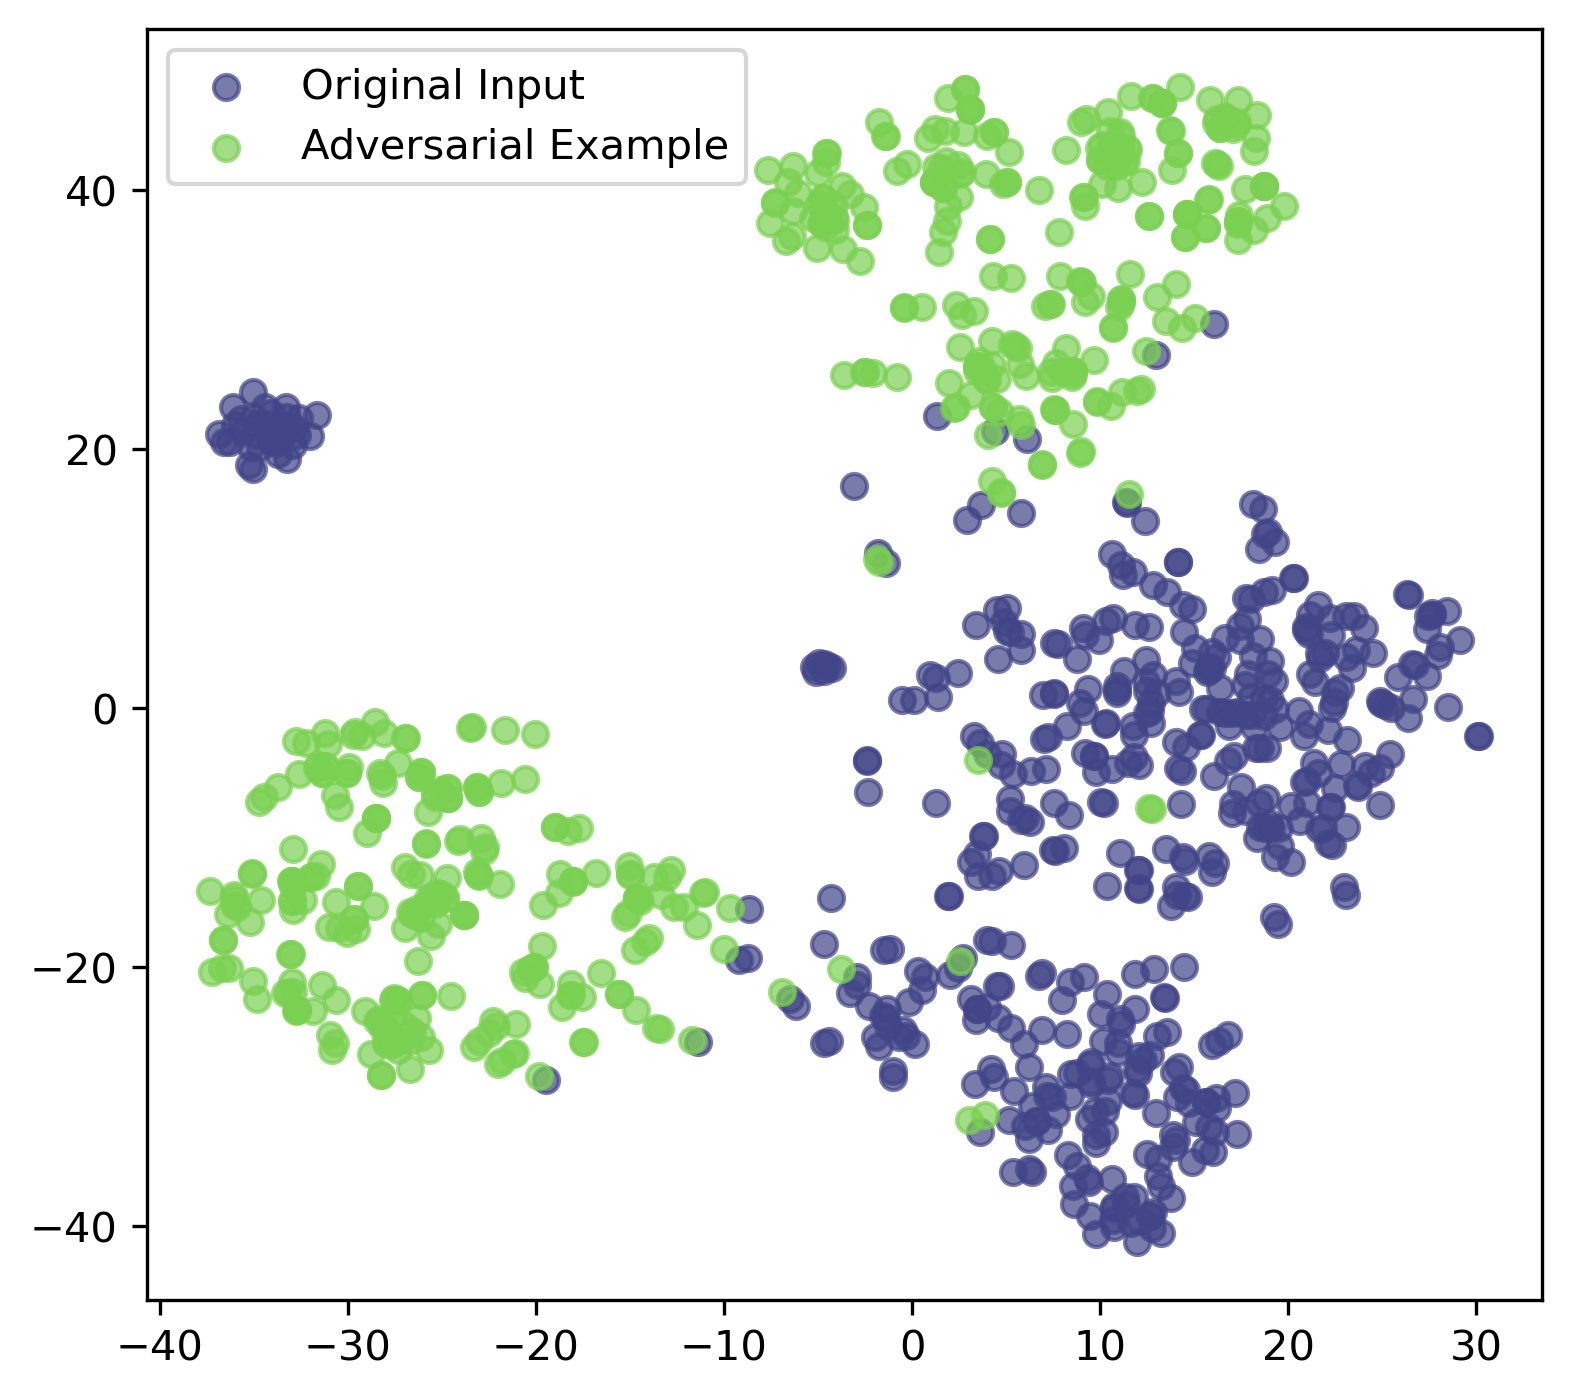

In [10]:
# test the model with the perturbed data
for attack in ["fgsm"]:
    print(f"Running {attack} attack")
    for eps in [0.5]:
        print(f"Running {attack} attack with epsilon={eps}")
        if attack == "noise":
            perturbed_data = attacks.random_noise_attack(sampled_true_prediction_X_tensor_500, epsilon=eps, 
                                                         one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "fgsm":
            perturbed_data = attacks.fgsm_attack(mlp, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, epsilon=eps,
                                              one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "pgd":
            num_iter = 10
            alpha = eps / num_iter
            perturbed_data = attacks.pgd_attack(mlp, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, eps, alpha, num_iter,
                                            one_hot_indices=onehot_indices, binary_indices=binary_indices)
        else:
            raise ValueError(f"Unknown attack: {attack}")
        
        perturbed_data_prediction = model_mlp.predict(mlp, perturbed_data, config["device"])
        attack_success_rate = torch.sum(perturbed_data_prediction != sampled_prediction_y_tensor_500).item() / len(sampled_prediction_y_tensor_500)
        print(f"Success rate: {attack_success_rate:.2f}")
        # detect the outliers
        print("Detecting outliers in all generated data")
        outliers = detect_outliers(perturbed_data, mu, cov_inv, threshold)
        print("Detecting outliers in the successful attacks")
        successful_attack_indices = torch.where(perturbed_data_prediction != sampled_prediction_y_tensor_500)[0]
        successful_attack_outliers = detect_outliers(perturbed_data[successful_attack_indices], mu, cov_inv, threshold)
        print()

    Results[f'{config["dataset"]}_{config["model"]}_{attack}'] = {
        "dataset": config["dataset"],
        "model": config["model"],
        "attack": attack,
        "success_rates": success_rates,
        "outliers_all": outliers_all,
        "outliers_successful_attacks": outliers_successful_attacks
    }
    print()

    np.random.seed(42)
    success_latent_vectors = perturbed_data[successful_attack_indices].clone().detach().numpy()
    # random_indices = np.random.choice(np.where(success_latent_vectors)[0], 150, replace=False)
    # latent_vectors_150 = success_latent_vectors[random_indices]
    func_to_vis(sampled_true_prediction_X_tensor_500.clone().detach().numpy(), success_latent_vectors)

#### Soft DT + Random Noise / FGSM / PGD

In [11]:
config = {
    "model": "SoftDecisionTree",
    "dataset": "adult_oh",
    "epochs": 100,
    "batch_size": 512,
    "device": device,
    "depth": 5,
    "lamda": 0.01
}

softdt = model_softdt.SoftDecisionTree(input_dim=total_num,
                                        output_dim=2,
                                        depth=config['depth'],
                                        lamda=config['lamda'],
                                        num_categorical=0,
                                        embedding_dims=[(0,0)],
                                        device=device).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(softdt.parameters(), lr=1e-3, weight_decay=1e-4)

# model_softdt.train(softdt, (X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(softdt.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

model_softdt.load(softdt, config['model'], config['dataset'], device=device, save_dir='models')

Model loaded from models/SoftDecisionTree_adult_oh.pt


SoftDecisionTree(
  (embedding_layers): ModuleList(
    (0): Embedding(0, 0)
  )
  (inner_nodes): Sequential(
    (0): Linear(in_features=102, out_features=31, bias=False)
    (1): Sigmoid()
  )
  (leaf_nodes): Linear(in_features=32, out_features=2, bias=False)
)

In [12]:
model_softdt.test(softdt, (X_test, y_test), config["device"])
true_prediction_indices, true_prediction_X_tensor, true_prediction_y_tensor = \
    pick_true_prediction(softdt, (X_test, y_test))
print("Indices of true predictions:", len(true_prediction_indices))

sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500 = sample_data_equal_class(true_prediction_X_tensor,
                                                                            labels=y_test[true_prediction_indices],
                                                                            n_samples=500)
sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)
sampled_prediction_y_tensor_500 = torch.tensor(sampled_prediction_y_tensor_500)

Accuracy: 85.83%
Indices of true predictions: 5178


/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/2073309891.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)


In [13]:
# test the model with the perturbed data
for attack in ["noise", "fgsm", "pgd"]:
    success_rates = []
    outliers_all = []
    outliers_successful_attacks = []
    print(f"Running {attack} attack")
    for eps in [i / 10 for i in range(1, 11)]:
        print(f"Running {attack} attack with epsilon={eps}")
        if attack == "noise":
            perturbed_data = attacks.random_noise_attack(sampled_true_prediction_X_tensor_500, epsilon=eps, 
                                                         one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "fgsm":
            perturbed_data = attacks.fgsm_attack(softdt, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, epsilon=eps,
                                              one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "pgd":
            num_iter = 10
            alpha = eps / num_iter
            perturbed_data = attacks.pgd_attack(softdt, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, eps, alpha, num_iter,
                                            one_hot_indices=onehot_indices, binary_indices=binary_indices)
        else:
            raise ValueError(f"Unknown attack: {attack}")
        
        perturbed_data_prediction = model_softdt.predict(softdt, perturbed_data, config["device"])
        attack_success_rate = torch.sum(perturbed_data_prediction != sampled_prediction_y_tensor_500).item() / len(sampled_prediction_y_tensor_500)
        print(f"Success rate: {attack_success_rate:.2f}")
        # detect the outliers
        print("Detecting outliers in all generated data")
        outliers = detect_outliers(perturbed_data, mu, cov_inv, threshold)
        print("Detecting outliers in the successful attacks")
        successful_attack_indices = torch.where(perturbed_data_prediction != sampled_prediction_y_tensor_500)[0]
        successful_attack_outliers = detect_outliers(perturbed_data[successful_attack_indices], mu, cov_inv, threshold)
        print()
        success_rates.append(attack_success_rate)
        outliers_all.append(outliers)
        outliers_successful_attacks.append(successful_attack_outliers)

    Results[f'{config["dataset"]}_{config["model"]}_{attack}'] = {
        "dataset": config["dataset"],
        "model": config["model"],
        "attack": attack,
        "success_rates": success_rates,
        "outliers_all": outliers_all,
        "outliers_successful_attacks": outliers_successful_attacks
    }
    print()


Running noise attack
Running noise attack with epsilon=0.1
Success rate: 0.05
Detecting outliers in all generated data
Detected 54/500 outliers
Detecting outliers in the successful attacks
Detected 1/24 outliers

Running noise attack with epsilon=0.2
Success rate: 0.05
Detecting outliers in all generated data
Detected 54/500 outliers
Detecting outliers in the successful attacks
Detected 1/24 outliers

Running noise attack with epsilon=0.3
Success rate: 0.05
Detecting outliers in all generated data
Detected 54/500 outliers
Detecting outliers in the successful attacks
Detected 1/25 outliers

Running noise attack with epsilon=0.4
Success rate: 0.06
Detecting outliers in all generated data
Detected 55/500 outliers
Detecting outliers in the successful attacks
Detected 3/29 outliers

Running noise attack with epsilon=0.5
Success rate: 0.05
Detecting outliers in all generated data
Detected 55/500 outliers
Detecting outliers in the successful attacks
Detected 2/23 outliers

Running noise attac

#### Tab Transformer + Random Noise / FGSM / PGD

In [14]:
# define the model
config = {
    "model": "TabTransformer",
    "dataset": "adult_oh",
    "epochs": 10,
    "batch_size": 512,
    "device": device
}

tabtrans = model_tabtrans.TabTransformer(categories=[],
                                      num_continuous=total_num,
                                      dim=trans_dim,
                                      depth=3,
                                      heads=4,
                                      dim_head=16,
                                      dim_out=2,
                                      ff_dropout=0.2,
                                      attn_dropout=0.2,
                                      )

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(tabtrans.parameters(), lr=1e-3, weight_decay=1e-4)

## Train
# model_tabtrans.train(tabtrans,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(tabtrans.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
tabtrans = model_tabtrans.load(tabtrans, config['model'], config['dataset'], device=device, save_dir='models')

Model loaded from models/TabTransformer_adult_oh.pt


In [15]:
model_tabtrans.test(tabtrans, (X_test, y_test), config["device"])
true_prediction_indices, true_prediction_X_tensor, true_prediction_y_tensor = \
    pick_true_prediction(tabtrans, (X_test, y_test))
print("Indices of true predictions:", len(true_prediction_indices))
sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500 = sample_data_equal_class(true_prediction_X_tensor,
                                                                            labels=y_test[true_prediction_indices],
                                                                            n_samples=500)
sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)
sampled_prediction_y_tensor_500 = torch.tensor(sampled_prediction_y_tensor_500)

Accuracy: 85.56%
Indices of true predictions: 5162


/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/4031907347.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)


In [16]:
# test the model with the perturbed data
for attack in ["noise", "fgsm", "pgd"]:
    success_rates = []
    outliers_all = []
    outliers_successful_attacks = []
    print(f"Running {attack} attack")
    for eps in [i / 10 for i in range(1, 11)]:
        print(f"Running {attack} attack with epsilon={eps}")
        if attack == "noise":
            perturbed_data = attacks.random_noise_attack(sampled_true_prediction_X_tensor_500, epsilon=eps, 
                                                         one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "fgsm":
            perturbed_data = attacks.fgsm_attack(tabtrans, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, epsilon=eps,
                                              one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "pgd":
            num_iter = 10
            alpha = eps / num_iter
            perturbed_data = attacks.pgd_attack(tabtrans, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, eps, alpha, num_iter,
                                            one_hot_indices=onehot_indices, binary_indices=binary_indices)
        else:
            raise ValueError(f"Unknown attack: {attack}")
        
        perturbed_data_prediction = model_tabtrans.predict(tabtrans, perturbed_data, config["device"])
        attack_success_rate = torch.sum(perturbed_data_prediction != sampled_prediction_y_tensor_500).item() / len(sampled_prediction_y_tensor_500)
        print(f"Success rate: {attack_success_rate:.2f}")
        # detect the outliers
        print("Detecting outliers in all generated data")
        outliers = detect_outliers(perturbed_data, mu, cov_inv, threshold)
        print("Detecting outliers in the successful attacks")
        successful_attack_indices = torch.where(perturbed_data_prediction != sampled_prediction_y_tensor_500)[0]
        successful_attack_outliers = detect_outliers(perturbed_data[successful_attack_indices], mu, cov_inv, threshold)
        print()
        success_rates.append(attack_success_rate)
        outliers_all.append(outliers)
        outliers_successful_attacks.append(successful_attack_outliers)

    Results[f'{config["dataset"]}_{config["model"]}_{attack}'] = {
        "dataset": config["dataset"],
        "model": config["model"],
        "attack": attack,
        "success_rates": success_rates,
        "outliers_all": outliers_all,
        "outliers_successful_attacks": outliers_successful_attacks
    }
    print()


Running noise attack
Running noise attack with epsilon=0.1
Success rate: 0.04
Detecting outliers in all generated data
Detected 49/500 outliers
Detecting outliers in the successful attacks
Detected 3/18 outliers

Running noise attack with epsilon=0.2
Success rate: 0.04
Detecting outliers in all generated data
Detected 49/500 outliers
Detecting outliers in the successful attacks
Detected 3/19 outliers

Running noise attack with epsilon=0.3
Success rate: 0.05
Detecting outliers in all generated data
Detected 49/500 outliers
Detecting outliers in the successful attacks
Detected 3/23 outliers

Running noise attack with epsilon=0.4
Success rate: 0.04
Detecting outliers in all generated data
Detected 49/500 outliers
Detecting outliers in the successful attacks
Detected 3/22 outliers

Running noise attack with epsilon=0.5
Success rate: 0.06
Detecting outliers in all generated data
Detected 49/500 outliers
Detecting outliers in the successful attacks
Detected 5/31 outliers

Running noise attac

### Phishing URL Dataset

In [17]:
# load the data from
X_train, X_val, X_test, y_train, y_val, y_test, preprocessor_state = \
    preprocess.load_and_use_saved_data('data/preprocessed/phishing_url_oh')

# feature numbers
feature_nums = preprocessor_state['processed_feature_nums']
total_num = X_train.shape[1]
continues_num = feature_nums['x_num']
categorical_num = total_num - continues_num
embedding_dims = feature_nums['embedding_dims']
categories = feature_nums['categories']
binary_num = feature_nums['binary_num']
total_categories = sum(categories)
trans_dim = math.ceil(math.sqrt(total_categories))
print(f'The num of embedding dim for Transformer is: {trans_dim}')
print(f'The num of categorical features is: {categorical_num}')
print(f'The num of continues features is: {continues_num}')
print(f'The num of total features is: {total_num}')
print(f'The num of binary features is: {binary_num}')

# convert categories to list of tuples (start, end)
onehot_indices = []
for i in range(len(categories)):
    if i == 0:
        onehot_indices.append((0, categories[i]))  # First category starts at 0
    else:
        onehot_indices.append((onehot_indices[i - 1][1], onehot_indices[i - 1][1] + categories[i]))
print(f"One-hot indices: {onehot_indices}")
if binary_num > 0:
    if len(categories) > 0:
        binary_indices = (onehot_indices[-1][1], onehot_indices[-1][1] + binary_num)
    else:
        binary_indices = (0, binary_num)
else:
    binary_indices = None
print(f"Binary indices: {binary_indices}")

mu, cov_inv, threshold = prepare_md(X_train)


Loaded data shapes:
X_train: torch.Size([8001, 88]), y_train: torch.Size([8001])
X_val: torch.Size([1143, 88]), y_val: torch.Size([1143])
X_test: torch.Size([2286, 88]), y_test: torch.Size([2286])
The num of embedding dim for Transformer is: 2
The num of categorical features is: 3
The num of continues features is: 85
The num of total features is: 88
The num of binary features is: 28
One-hot indices: [(0, 3)]
Binary indices: (3, 31)
Chi-Squared Threshold: 110.89800282268448


#### MLP + Random Noise / FGSM / PGD

In [18]:

config = {
    "model": "MLP",
    "dataset": "phishing_url_oh",
    "epochs": 100,
    "batch_size": 128,
    "device": device,
    "hidden_dims": [64, 32, 16],
}

mlp = model_mlp.MLP(input_dim=total_num, 
                    hidden_dims=config['hidden_dims'],
                    output_dim=2,
                    num_categorical=0,
                    embedding_dims=[(0,0)],
                    dropout=0.2
                    ).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-4, weight_decay=1e-4)

# model_mlp.train(mlp,(X_train, y_train), (X_val, y_val), criterion, optimizer, mlp_config)
# torch.save(mlp.state_dict(), f"models/{mlp_config['model']}_{mlp_config['dataset']}.pt")

## Load
mlp = model_mlp.load(mlp, config['model'], config['dataset'], device=device, save_dir='models')

Model loaded from models/MLP_phishing_url_oh.pt


In [19]:
model_mlp.test(mlp, (X_test, y_test), config["device"])
true_prediction_indices, true_prediction_X_tensor, true_prediction_y_tensor = \
    pick_true_prediction(mlp, (X_test, y_test))
print("Indices of true predictions:", len(true_prediction_indices))
sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500 = sample_data_equal_class(true_prediction_X_tensor,
                                                                            labels=y_test[true_prediction_indices],
                                                                            n_samples=500)
sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)
sampled_prediction_y_tensor_500 = torch.tensor(sampled_prediction_y_tensor_500)

Accuracy: 96.63%
Indices of true predictions: 2209


/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/2791026158.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)


In [20]:
# test the model with the perturbed data
for attack in ["noise", "fgsm", "pgd"]:
    success_rates = []
    outliers_all = []
    outliers_successful_attacks = []
    print(f"Running {attack} attack")
    for eps in [i / 10 for i in range(1, 11)]:
        print(f"Running {attack} attack with epsilon={eps}")
        if attack == "noise":
            perturbed_data = attacks.random_noise_attack(sampled_true_prediction_X_tensor_500, epsilon=eps, 
                                                         one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "fgsm":
            perturbed_data = attacks.fgsm_attack(mlp, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, epsilon=eps,
                                              one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "pgd":
            num_iter = 10
            alpha = eps / num_iter
            perturbed_data = attacks.pgd_attack(mlp, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, eps, alpha, num_iter,
                                            one_hot_indices=onehot_indices, binary_indices=binary_indices)
        else:
            raise ValueError(f"Unknown attack: {attack}")
        
        perturbed_data_prediction = model_mlp.predict(mlp, perturbed_data, config["device"])
        attack_success_rate = torch.sum(perturbed_data_prediction != sampled_prediction_y_tensor_500).item() / len(sampled_prediction_y_tensor_500)
        print(f"Success rate: {attack_success_rate:.2f}")
        # detect the outliers
        print("Detecting outliers in all generated data")
        outliers = detect_outliers(perturbed_data, mu, cov_inv, threshold)
        print("Detecting outliers in the successful attacks")
        successful_attack_indices = torch.where(perturbed_data_prediction != sampled_prediction_y_tensor_500)[0]
        successful_attack_outliers = detect_outliers(perturbed_data[successful_attack_indices], mu, cov_inv, threshold)
        print()
        success_rates.append(attack_success_rate)
        outliers_all.append(outliers)
        outliers_successful_attacks.append(successful_attack_outliers)

    Results[f'{config["dataset"]}_{config["model"]}_{attack}'] = {
        "dataset": config["dataset"],
        "model": config["model"],
        "attack": attack,
        "success_rates": success_rates,
        "outliers_all": outliers_all,
        "outliers_successful_attacks": outliers_successful_attacks
    }
    print()


Running noise attack
Running noise attack with epsilon=0.1
Success rate: 0.03
Detecting outliers in all generated data
Detected 461/500 outliers
Detecting outliers in the successful attacks
Detected 16/16 outliers

Running noise attack with epsilon=0.2
Success rate: 0.03
Detecting outliers in all generated data
Detected 464/500 outliers
Detecting outliers in the successful attacks
Detected 13/14 outliers

Running noise attack with epsilon=0.3
Success rate: 0.03
Detecting outliers in all generated data
Detected 469/500 outliers
Detecting outliers in the successful attacks
Detected 13/13 outliers

Running noise attack with epsilon=0.4
Success rate: 0.02
Detecting outliers in all generated data
Detected 470/500 outliers
Detecting outliers in the successful attacks
Detected 11/12 outliers

Running noise attack with epsilon=0.5
Success rate: 0.03
Detecting outliers in all generated data
Detected 472/500 outliers
Detecting outliers in the successful attacks
Detected 14/14 outliers

Running n

#### Soft DT + Random Noise / FGSM / PGD

In [21]:
config = {
    "model": "SoftDecisionTree",
    "dataset": "phishing_url_oh",
    "epochs": 100,
    "batch_size": 512,
    "device": device,
    "depth": 5,
    "lamda": 0.01
}

softdt = model_softdt.SoftDecisionTree(input_dim=total_num,
                                        output_dim=2,
                                        depth=config['depth'],
                                        lamda=config['lamda'],
                                        num_categorical=0,
                                        embedding_dims=[(0,0)],
                                        device=device).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(softdt.parameters(), lr=1e-3, weight_decay=1e-4)

# model_softdt.train(softdt, (X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(softdt.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

model_softdt.load(softdt, config['model'], config['dataset'], device=device, save_dir='models')

Model loaded from models/SoftDecisionTree_phishing_url_oh.pt


SoftDecisionTree(
  (embedding_layers): ModuleList(
    (0): Embedding(0, 0)
  )
  (inner_nodes): Sequential(
    (0): Linear(in_features=89, out_features=31, bias=False)
    (1): Sigmoid()
  )
  (leaf_nodes): Linear(in_features=32, out_features=2, bias=False)
)

In [22]:
model_softdt.test(softdt, (X_test, y_test), config["device"])
true_prediction_indices, true_prediction_X_tensor, true_prediction_y_tensor = \
    pick_true_prediction(softdt, (X_test, y_test))
print("Indices of true predictions:", len(true_prediction_indices))

sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500 = sample_data_equal_class(true_prediction_X_tensor,
                                                                            labels=y_test[true_prediction_indices],
                                                                            n_samples=500)
sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)
sampled_prediction_y_tensor_500 = torch.tensor(sampled_prediction_y_tensor_500)

Accuracy: 96.06%
Indices of true predictions: 2196


/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/2073309891.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)


In [23]:
# test the model with the perturbed data
for attack in ["noise", "fgsm", "pgd"]:
    success_rates = []
    outliers_all = []
    outliers_successful_attacks = []
    print(f"Running {attack} attack")
    for eps in [i / 10 for i in range(1, 11)]:
        print(f"Running {attack} attack with epsilon={eps}")
        if attack == "noise":
            perturbed_data = attacks.random_noise_attack(sampled_true_prediction_X_tensor_500, epsilon=eps, 
                                                         one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "fgsm":
            perturbed_data = attacks.fgsm_attack(softdt, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, epsilon=eps,
                                              one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "pgd":
            num_iter = 10
            alpha = eps / num_iter
            perturbed_data = attacks.pgd_attack(softdt, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, eps, alpha, num_iter,
                                            one_hot_indices=onehot_indices, binary_indices=binary_indices)
        else:
            raise ValueError(f"Unknown attack: {attack}")
        
        perturbed_data_prediction = model_softdt.predict(softdt, perturbed_data, config["device"])
        attack_success_rate = torch.sum(perturbed_data_prediction != sampled_prediction_y_tensor_500).item() / len(sampled_prediction_y_tensor_500)
        print(f"Success rate: {attack_success_rate:.2f}")
        # detect the outliers
        print("Detecting outliers in all generated data")
        outliers = detect_outliers(perturbed_data, mu, cov_inv, threshold)
        print("Detecting outliers in the successful attacks")
        successful_attack_indices = torch.where(perturbed_data_prediction != sampled_prediction_y_tensor_500)[0]
        successful_attack_outliers = detect_outliers(perturbed_data[successful_attack_indices], mu, cov_inv, threshold)
        print()
        success_rates.append(attack_success_rate)
        outliers_all.append(outliers)
        outliers_successful_attacks.append(successful_attack_outliers)

    Results[f'{config["dataset"]}_{config["model"]}_{attack}'] = {
        "dataset": config["dataset"],
        "model": config["model"],
        "attack": attack,
        "success_rates": success_rates,
        "outliers_all": outliers_all,
        "outliers_successful_attacks": outliers_successful_attacks
    }
    print()


Running noise attack
Running noise attack with epsilon=0.1
Success rate: 0.02
Detecting outliers in all generated data
Detected 462/500 outliers
Detecting outliers in the successful attacks
Detected 10/12 outliers

Running noise attack with epsilon=0.2
Success rate: 0.02
Detecting outliers in all generated data
Detected 475/500 outliers
Detecting outliers in the successful attacks
Detected 12/12 outliers

Running noise attack with epsilon=0.3
Success rate: 0.02
Detecting outliers in all generated data
Detected 466/500 outliers
Detecting outliers in the successful attacks
Detected 8/9 outliers

Running noise attack with epsilon=0.4
Success rate: 0.02
Detecting outliers in all generated data
Detected 468/500 outliers
Detecting outliers in the successful attacks
Detected 12/12 outliers

Running noise attack with epsilon=0.5
Success rate: 0.02
Detecting outliers in all generated data
Detected 478/500 outliers
Detecting outliers in the successful attacks
Detected 10/10 outliers

Running noi

#### Tab Transformer + Random Noise / FGSM / PGD

In [24]:
# define the model
config = {
    "model": "TabTransformer",
    "dataset": "phishing_url_oh",
    "epochs": 50,
    "batch_size": 512,
    "device": device
}

tabtrans = model_tabtrans.TabTransformer(categories=[],
                                      num_continuous=total_num,
                                      dim=trans_dim,
                                      depth=3,
                                      heads=4,
                                      dim_head=8,
                                      dim_out=2,
                                      ff_dropout=0.2,
                                      attn_dropout=0.2,
                                      )

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(tabtrans.parameters(), lr=1e-4, weight_decay=1e-4)

## Train
# model_tabtrans.train(tabtrans,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(tabtrans.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
tabtrans = model_tabtrans.load(tabtrans, config['model'], config['dataset'], device=device, save_dir='models')

Model loaded from models/TabTransformer_phishing_url_oh.pt


In [25]:
model_tabtrans.test(tabtrans, (X_test, y_test), config["device"])
true_prediction_indices, true_prediction_X_tensor, true_prediction_y_tensor = \
    pick_true_prediction(tabtrans, (X_test, y_test))
print("Indices of true predictions:", len(true_prediction_indices))
sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500 = sample_data_equal_class(true_prediction_X_tensor,
                                                                            labels=y_test[true_prediction_indices],
                                                                            n_samples=500)
sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)
sampled_prediction_y_tensor_500 = torch.tensor(sampled_prediction_y_tensor_500)

Accuracy: 96.72%
Indices of true predictions: 2211


/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/4031907347.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)


In [26]:
# test the model with the perturbed data
for attack in ["noise", "fgsm", "pgd"]:
    success_rates = []
    outliers_all = []
    outliers_successful_attacks = []
    print(f"Running {attack} attack")
    for eps in [i / 10 for i in range(1, 11)]:
        print(f"Running {attack} attack with epsilon={eps}")
        if attack == "noise":
            perturbed_data = attacks.random_noise_attack(sampled_true_prediction_X_tensor_500, epsilon=eps, 
                                                         one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "fgsm":
            perturbed_data = attacks.fgsm_attack(tabtrans, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, epsilon=eps,
                                              one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "pgd":
            num_iter = 10
            alpha = eps / num_iter
            perturbed_data = attacks.pgd_attack(tabtrans, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, eps, alpha, num_iter,
                                            one_hot_indices=onehot_indices, binary_indices=binary_indices)
        else:
            raise ValueError(f"Unknown attack: {attack}")
        
        perturbed_data_prediction = model_tabtrans.predict(tabtrans, perturbed_data, config["device"])
        attack_success_rate = torch.sum(perturbed_data_prediction != sampled_prediction_y_tensor_500).item() / len(sampled_prediction_y_tensor_500)
        print(f"Success rate: {attack_success_rate:.2f}")
        # detect the outliers
        print("Detecting outliers in all generated data")
        outliers = detect_outliers(perturbed_data, mu, cov_inv, threshold)
        print("Detecting outliers in the successful attacks")
        successful_attack_indices = torch.where(perturbed_data_prediction != sampled_prediction_y_tensor_500)[0]
        successful_attack_outliers = detect_outliers(perturbed_data[successful_attack_indices], mu, cov_inv, threshold)
        print()
        success_rates.append(attack_success_rate)
        outliers_all.append(outliers)
        outliers_successful_attacks.append(successful_attack_outliers)

    Results[f'{config["dataset"]}_{config["model"]}_{attack}'] = {
        "dataset": config["dataset"],
        "model": config["model"],
        "attack": attack,
        "success_rates": success_rates,
        "outliers_all": outliers_all,
        "outliers_successful_attacks": outliers_successful_attacks
    }
    print()


Running noise attack
Running noise attack with epsilon=0.1
Success rate: 0.05
Detecting outliers in all generated data
Detected 459/500 outliers
Detecting outliers in the successful attacks
Detected 25/27 outliers

Running noise attack with epsilon=0.2
Success rate: 0.05
Detecting outliers in all generated data
Detected 473/500 outliers
Detecting outliers in the successful attacks
Detected 27/27 outliers

Running noise attack with epsilon=0.3
Success rate: 0.06
Detecting outliers in all generated data
Detected 460/500 outliers
Detecting outliers in the successful attacks
Detected 29/31 outliers

Running noise attack with epsilon=0.4
Success rate: 0.05
Detecting outliers in all generated data
Detected 462/500 outliers
Detecting outliers in the successful attacks
Detected 23/26 outliers

Running noise attack with epsilon=0.5
Success rate: 0.04
Detecting outliers in all generated data
Detected 469/500 outliers
Detecting outliers in the successful attacks
Detected 20/21 outliers

Running n

### Pendigits Dataset

In [27]:
# load the data from
X_train, X_val, X_test, y_train, y_val, y_test, preprocessor_state = \
    preprocess.load_and_use_saved_data('data/preprocessed/pendigit_oh')

# feature numbers
feature_nums = preprocessor_state['processed_feature_nums']
total_num = X_train.shape[1]
continues_num = feature_nums['x_num']
categorical_num = total_num - continues_num
embedding_dims = feature_nums['embedding_dims']
categories = feature_nums['categories']
binary_num = feature_nums['binary_num']
total_categories = sum(categories)
trans_dim = math.ceil(math.sqrt(total_categories))
print(f'The num of embedding dim for Transformer is: {trans_dim}')
print(f'The num of categorical features is: {categorical_num}')
print(f'The num of continues features is: {continues_num}')
print(f'The num of total features is: {total_num}')
print(f'The num of binary features is: {binary_num}')

# convert categories to list of tuples (start, end)
if len(categories)>0:
    onehot_indices = []
    for i in range(len(categories)):
        if i == 0:
            onehot_indices.append((0, categories[i]))  # First category starts at 0
        else:
            onehot_indices.append((onehot_indices[i - 1][1], onehot_indices[i - 1][1] + categories[i]))
    print(f"One-hot indices: {onehot_indices}")
else:
    onehot_indices = None
if binary_num > 0:
    if len(categories) > 0:
        binary_indices = (onehot_indices[-1][1], onehot_indices[-1][1] + binary_num)
    else:
        binary_indices = (0, binary_num)
else:
    binary_indices = None
print(f"Binary indices: {binary_indices}")

mu, cov_inv, threshold = prepare_md(X_train)


Loaded data shapes:
X_train: torch.Size([7693, 16]), y_train: torch.Size([7693])
X_val: torch.Size([1100, 16]), y_val: torch.Size([1100])
X_test: torch.Size([2199, 16]), y_test: torch.Size([2199])
The num of embedding dim for Transformer is: 0
The num of categorical features is: 0
The num of continues features is: 16
The num of total features is: 16
The num of binary features is: 0
Binary indices: None
Chi-Squared Threshold: 26.296227604864242


#### MLP + Random Noise / FGSM / PGD

In [28]:
# define the model

config = {
    "model": "MLP",
    "dataset": "pendigit_oh",
    "epochs": 200,
    "batch_size": 512,
    "device": device,
    "hidden_dims": [32, 16],
}

mlp = model_mlp.MLP(input_dim=total_num, 
                    hidden_dims=config['hidden_dims'],
                    output_dim=10,
                    num_categorical=0,
                    embedding_dims=[(0,0)],
                    dropout=0.2
                    ).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)

# model_mlp.train(mlp,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(mlp.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
mlp = model_mlp.load(mlp, config['model'], config['dataset'], device=device, save_dir='models')

Model loaded from models/MLP_pendigit_oh.pt


In [29]:
model_mlp.test(mlp, (X_test, y_test), config["device"])
true_prediction_indices, true_prediction_X_tensor, true_prediction_y_tensor = \
    pick_true_prediction(mlp, (X_test, y_test))
print("Indices of true predictions:", len(true_prediction_indices))
sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500 = sample_data_equal_class(true_prediction_X_tensor,
                                                                            labels=y_test[true_prediction_indices],
                                                                            n_samples=500)
sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)
sampled_prediction_y_tensor_500 = torch.tensor(sampled_prediction_y_tensor_500)

Accuracy: 97.82%
Indices of true predictions: 2151


/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/2791026158.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)


In [30]:
# test the model with the perturbed data
for attack in ["noise", "fgsm", "pgd"]:
    success_rates = []
    outliers_all = []
    outliers_successful_attacks = []
    print(f"Running {attack} attack")
    for eps in [i / 10 for i in range(1, 11)]:
        print(f"Running {attack} attack with epsilon={eps}")
        if attack == "noise":
            perturbed_data = attacks.random_noise_attack(sampled_true_prediction_X_tensor_500, epsilon=eps, 
                                                         one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "fgsm":
            perturbed_data = attacks.fgsm_attack(mlp, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, epsilon=eps,
                                              one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "pgd":
            num_iter = 10
            alpha = eps / num_iter
            perturbed_data = attacks.pgd_attack(mlp, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, eps, alpha, num_iter,
                                            one_hot_indices=onehot_indices, binary_indices=binary_indices)
        else:
            raise ValueError(f"Unknown attack: {attack}")
        
        perturbed_data_prediction = model_mlp.predict(mlp, perturbed_data, config["device"])
        attack_success_rate = torch.sum(perturbed_data_prediction != sampled_prediction_y_tensor_500).item() / len(sampled_prediction_y_tensor_500)
        print(f"Success rate: {attack_success_rate:.2f}")
        # detect the outliers
        print("Detecting outliers in all generated data")
        outliers = detect_outliers(perturbed_data, mu, cov_inv, threshold)
        print("Detecting outliers in the successful attacks")
        successful_attack_indices = torch.where(perturbed_data_prediction != sampled_prediction_y_tensor_500)[0]
        successful_attack_outliers = detect_outliers(perturbed_data[successful_attack_indices], mu, cov_inv, threshold)
        print()
        success_rates.append(attack_success_rate)
        outliers_all.append(outliers)
        outliers_successful_attacks.append(successful_attack_outliers)

    Results[f'{config["dataset"]}_{config["model"]}_{attack}'] = {
        "dataset": config["dataset"],
        "model": config["model"],
        "attack": attack,
        "success_rates": success_rates,
        "outliers_all": outliers_all,
        "outliers_successful_attacks": outliers_successful_attacks
    }
    print()


Running noise attack
Running noise attack with epsilon=0.1
Success rate: 0.46
Detecting outliers in all generated data
Detected 1/500 outliers
Detecting outliers in the successful attacks
Detected 0/232 outliers

Running noise attack with epsilon=0.2
Success rate: 0.47
Detecting outliers in all generated data
Detected 0/500 outliers
Detecting outliers in the successful attacks
Detected 0/237 outliers

Running noise attack with epsilon=0.3
Success rate: 0.47
Detecting outliers in all generated data
Detected 1/500 outliers
Detecting outliers in the successful attacks
Detected 0/236 outliers

Running noise attack with epsilon=0.4
Success rate: 0.45
Detecting outliers in all generated data
Detected 1/500 outliers
Detecting outliers in the successful attacks
Detected 1/225 outliers

Running noise attack with epsilon=0.5
Success rate: 0.51
Detecting outliers in all generated data
Detected 7/500 outliers
Detecting outliers in the successful attacks
Detected 2/256 outliers

Running noise attac

#### Soft DT + Random Noise / FGSM / PGD

In [31]:
config = {
    "model": "SoftDecisionTree",
    "dataset": "pendigit_oh",
    "epochs": 250,
    "batch_size": 512,
    "device": device,
    "depth": 5,
    "lamda": 0.01
}

softdt = model_softdt.SoftDecisionTree(input_dim=total_num,
                                        output_dim=10,
                                        depth=config['depth'],
                                        lamda=config['lamda'],
                                        num_categorical=0,
                                        embedding_dims=[(0,0)],
                                        device=device).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(softdt.parameters(), lr=1e-3, weight_decay=1e-4)

# model_softdt.train(softdt, (X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(softdt.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

model_softdt.load(softdt, config['model'], config['dataset'], device=device, save_dir='models')

Model loaded from models/SoftDecisionTree_pendigit_oh.pt


SoftDecisionTree(
  (embedding_layers): ModuleList(
    (0): Embedding(0, 0)
  )
  (inner_nodes): Sequential(
    (0): Linear(in_features=17, out_features=31, bias=False)
    (1): Sigmoid()
  )
  (leaf_nodes): Linear(in_features=32, out_features=10, bias=False)
)

In [32]:
model_softdt.test(softdt, (X_test, y_test), config["device"])
true_prediction_indices, true_prediction_X_tensor, true_prediction_y_tensor = \
    pick_true_prediction(softdt, (X_test, y_test))
print("Indices of true predictions:", len(true_prediction_indices))

sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500 = sample_data_equal_class(true_prediction_X_tensor,
                                                                            labels=y_test[true_prediction_indices],
                                                                            n_samples=500)
sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)
sampled_prediction_y_tensor_500 = torch.tensor(sampled_prediction_y_tensor_500)

Accuracy: 96.86%
Indices of true predictions: 2130


/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/2073309891.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)


In [33]:
# test the model with the perturbed data
for attack in ["noise", "fgsm", "pgd"]:
    success_rates = []
    outliers_all = []
    outliers_successful_attacks = []
    print(f"Running {attack} attack")
    for eps in [i / 10 for i in range(1, 11)]:
        print(f"Running {attack} attack with epsilon={eps}")
        if attack == "noise":
            perturbed_data = attacks.random_noise_attack(sampled_true_prediction_X_tensor_500, epsilon=eps, 
                                                         one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "fgsm":
            perturbed_data = attacks.fgsm_attack(softdt, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, epsilon=eps,
                                              one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "pgd":
            num_iter = 10
            alpha = eps / num_iter
            perturbed_data = attacks.pgd_attack(softdt, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, eps, alpha, num_iter,
                                            one_hot_indices=onehot_indices, binary_indices=binary_indices)
        else:
            raise ValueError(f"Unknown attack: {attack}")
        
        perturbed_data_prediction = model_softdt.predict(softdt, perturbed_data, config["device"])
        attack_success_rate = torch.sum(perturbed_data_prediction != sampled_prediction_y_tensor_500).item() / len(sampled_prediction_y_tensor_500)
        print(f"Success rate: {attack_success_rate:.2f}")
        # detect the outliers
        print("Detecting outliers in all generated data")
        outliers = detect_outliers(perturbed_data, mu, cov_inv, threshold)
        print("Detecting outliers in the successful attacks")
        successful_attack_indices = torch.where(perturbed_data_prediction != sampled_prediction_y_tensor_500)[0]
        successful_attack_outliers = detect_outliers(perturbed_data[successful_attack_indices], mu, cov_inv, threshold)
        print()
        success_rates.append(attack_success_rate)
        outliers_all.append(outliers)
        outliers_successful_attacks.append(successful_attack_outliers)

    Results[f'{config["dataset"]}_{config["model"]}_{attack}'] = {
        "dataset": config["dataset"],
        "model": config["model"],
        "attack": attack,
        "success_rates": success_rates,
        "outliers_all": outliers_all,
        "outliers_successful_attacks": outliers_successful_attacks
    }
    print()


Running noise attack
Running noise attack with epsilon=0.1
Success rate: 0.48
Detecting outliers in all generated data
Detected 0/500 outliers
Detecting outliers in the successful attacks
Detected 0/240 outliers

Running noise attack with epsilon=0.2
Success rate: 0.47
Detecting outliers in all generated data
Detected 1/500 outliers
Detecting outliers in the successful attacks
Detected 0/235 outliers

Running noise attack with epsilon=0.3
Success rate: 0.48
Detecting outliers in all generated data
Detected 1/500 outliers
Detecting outliers in the successful attacks
Detected 0/239 outliers

Running noise attack with epsilon=0.4
Success rate: 0.48
Detecting outliers in all generated data
Detected 1/500 outliers
Detecting outliers in the successful attacks
Detected 0/238 outliers

Running noise attack with epsilon=0.5
Success rate: 0.49
Detecting outliers in all generated data
Detected 3/500 outliers
Detecting outliers in the successful attacks
Detected 0/245 outliers

Running noise attac

#### Tab Transformer + Random Noise / FGSM / PGD

In [34]:
# define the model
config = {
    "model": "TabTransformer",
    "dataset": "pendigit_oh",
    "epochs": 250,
    "batch_size": 512,
    "device": device
}

tabtrans = model_tabtrans.TabTransformer(categories=[],
                                      num_continuous=total_num,
                                      dim=trans_dim,
                                      depth=3,
                                      heads=4,
                                      dim_head=8,
                                      dim_out=10,
                                      ff_dropout=0.2,
                                      attn_dropout=0.2,
                                      )

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(tabtrans.parameters(), lr=1e-4, weight_decay=1e-4)

## Train
# model_tabtrans.train(tabtrans,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(tabtrans.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
tabtrans = model_tabtrans.load(tabtrans, config['model'], config['dataset'], device=device, save_dir='models')

Model loaded from models/TabTransformer_pendigit_oh.pt


/opt/homebrew/Caskroom/miniforge/base/envs/VAE-Attack/lib/python3.11/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


In [35]:
model_tabtrans.test(tabtrans, (X_test, y_test), config["device"])
true_prediction_indices, true_prediction_X_tensor, true_prediction_y_tensor = \
    pick_true_prediction(tabtrans, (X_test, y_test))
print("Indices of true predictions:", len(true_prediction_indices))
sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500 = sample_data_equal_class(true_prediction_X_tensor,
                                                                            labels=y_test[true_prediction_indices],
                                                                            n_samples=500)
sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)
sampled_prediction_y_tensor_500 = torch.tensor(sampled_prediction_y_tensor_500)

Accuracy: 98.04%
Indices of true predictions: 2156


/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/4031907347.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)


In [36]:
# test the model with the perturbed data
for attack in ["noise", "fgsm", "pgd"]:
    success_rates = []
    outliers_all = []
    outliers_successful_attacks = []
    print(f"Running {attack} attack")
    for eps in [i / 10 for i in range(1, 11)]:
        print(f"Running {attack} attack with epsilon={eps}")
        if attack == "noise":
            perturbed_data = attacks.random_noise_attack(sampled_true_prediction_X_tensor_500, epsilon=eps, 
                                                         one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "fgsm":
            perturbed_data = attacks.fgsm_attack(tabtrans, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, epsilon=eps,
                                              one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "pgd":
            num_iter = 10
            alpha = eps / num_iter
            perturbed_data = attacks.pgd_attack(tabtrans, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, eps, alpha, num_iter,
                                            one_hot_indices=onehot_indices, binary_indices=binary_indices)
        else:
            raise ValueError(f"Unknown attack: {attack}")
        
        perturbed_data_prediction = model_tabtrans.predict(tabtrans, perturbed_data, config["device"])
        attack_success_rate = torch.sum(perturbed_data_prediction != sampled_prediction_y_tensor_500).item() / len(sampled_prediction_y_tensor_500)
        print(f"Success rate: {attack_success_rate:.2f}")
        # detect the outliers
        print("Detecting outliers in all generated data")
        outliers = detect_outliers(perturbed_data, mu, cov_inv, threshold)
        print("Detecting outliers in the successful attacks")
        successful_attack_indices = torch.where(perturbed_data_prediction != sampled_prediction_y_tensor_500)[0]
        successful_attack_outliers = detect_outliers(perturbed_data[successful_attack_indices], mu, cov_inv, threshold)
        print()
        success_rates.append(attack_success_rate)
        outliers_all.append(outliers)
        outliers_successful_attacks.append(successful_attack_outliers)

    Results[f'{config["dataset"]}_{config["model"]}_{attack}'] = {
        "dataset": config["dataset"],
        "model": config["model"],
        "attack": attack,
        "success_rates": success_rates,
        "outliers_all": outliers_all,
        "outliers_successful_attacks": outliers_successful_attacks
    }
    print()


Running noise attack
Running noise attack with epsilon=0.1
Success rate: 0.11
Detecting outliers in all generated data
Detected 0/500 outliers
Detecting outliers in the successful attacks
Detected 0/55 outliers

Running noise attack with epsilon=0.2
Success rate: 0.11
Detecting outliers in all generated data
Detected 0/500 outliers
Detecting outliers in the successful attacks
Detected 0/53 outliers

Running noise attack with epsilon=0.3
Success rate: 0.10
Detecting outliers in all generated data
Detected 0/500 outliers
Detecting outliers in the successful attacks
Detected 0/51 outliers

Running noise attack with epsilon=0.4
Success rate: 0.11
Detecting outliers in all generated data
Detected 1/500 outliers
Detecting outliers in the successful attacks
Detected 0/53 outliers

Running noise attack with epsilon=0.5
Success rate: 0.13
Detecting outliers in all generated data
Detected 1/500 outliers
Detecting outliers in the successful attacks
Detected 0/65 outliers

Running noise attack wit

### electricity

In [37]:
# load the data from
X_train, X_val, X_test, y_train, y_val, y_test, preprocessor_state = \
    preprocess.load_and_use_saved_data('data/preprocessed/electricity_oh')

# feature numbers
feature_nums = preprocessor_state['processed_feature_nums']
total_num = X_train.shape[1]
continues_num = feature_nums['x_num']
categorical_num = total_num - continues_num
embedding_dims = feature_nums['embedding_dims']
categories = feature_nums['categories']
binary_num = feature_nums['binary_num']
total_categories = sum(categories)
trans_dim = math.ceil(math.sqrt(total_categories))
print(f'The num of embedding dim for Transformer is: {trans_dim}')
print(f'The num of categorical features is: {categorical_num}')
print(f'The num of continues features is: {continues_num}')
print(f'The num of total features is: {total_num}')
print(f'The num of binary features is: {binary_num}')

# convert categories to list of tuples (start, end)
if len(categories)>0:
    onehot_indices = []
    for i in range(len(categories)):
        if i == 0:
            onehot_indices.append((0, categories[i]))  # First category starts at 0
        else:
            onehot_indices.append((onehot_indices[i - 1][1], onehot_indices[i - 1][1] + categories[i]))
    print(f"One-hot indices: {onehot_indices}")
else:
    onehot_indices = None
if binary_num > 0:
    if len(categories) > 0:
        binary_indices = (onehot_indices[-1][1], onehot_indices[-1][1] + binary_num)
    else:
        binary_indices = (0, binary_num)
else:
    binary_indices = None
print(f"Binary indices: {binary_indices}")

mu, cov_inv, threshold = prepare_md(X_train)


Loaded data shapes:
X_train: torch.Size([31717, 14]), y_train: torch.Size([31717])
X_val: torch.Size([4532, 14]), y_val: torch.Size([4532])
X_test: torch.Size([9063, 14]), y_test: torch.Size([9063])
The num of embedding dim for Transformer is: 3
The num of categorical features is: 7
The num of continues features is: 7
The num of total features is: 14
The num of binary features is: 0
One-hot indices: [(0, 7)]
Binary indices: None
Chi-Squared Threshold: 23.68479130484058


#### MLP + Random Noise / FGSM / PGD

In [38]:
# define the model

config = {
    "model": "MLP",
    "dataset": "electricity_oh",
    "epochs": 200,
    "batch_size": 512,
    "device": device,
    "hidden_dims": [32, 16],
}

mlp = model_mlp.MLP(input_dim=total_num, 
                    hidden_dims=config['hidden_dims'],
                    output_dim=2,
                    num_categorical=0,
                    embedding_dims=[(0,0)],
                    dropout=0.1
                    ).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)

# model_mlp.train(mlp,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(mlp.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
mlp = model_mlp.load(mlp, config['model'], config['dataset'], device=device, save_dir='models')

Model loaded from models/MLP_electricity_oh.pt


In [39]:
model_mlp.test(mlp, (X_test, y_test), config["device"])
true_prediction_indices, true_prediction_X_tensor, true_prediction_y_tensor = \
    pick_true_prediction(mlp, (X_test, y_test))
print("Indices of true predictions:", len(true_prediction_indices))
sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500 = sample_data_equal_class(true_prediction_X_tensor,
                                                                            labels=y_test[true_prediction_indices],
                                                                            n_samples=500)
sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)
sampled_prediction_y_tensor_500 = torch.tensor(sampled_prediction_y_tensor_500)

Accuracy: 81.18%
Indices of true predictions: 7357


/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/2791026158.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)


In [40]:
# test the model with the perturbed data
for attack in ["noise", "fgsm", "pgd"]:
    success_rates = []
    outliers_all = []
    outliers_successful_attacks = []
    print(f"Running {attack} attack")
    for eps in [i / 10 for i in range(1, 11)]:
        print(f"Running {attack} attack with epsilon={eps}")
        if attack == "noise":
            perturbed_data = attacks.random_noise_attack(sampled_true_prediction_X_tensor_500, epsilon=eps, 
                                                         one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "fgsm":
            perturbed_data = attacks.fgsm_attack(mlp, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, epsilon=eps,
                                              one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "pgd":
            num_iter = 10
            alpha = eps / num_iter
            perturbed_data = attacks.pgd_attack(mlp, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, eps, alpha, num_iter,
                                            one_hot_indices=onehot_indices, binary_indices=binary_indices)
        else:
            raise ValueError(f"Unknown attack: {attack}")
        
        perturbed_data_prediction = model_mlp.predict(mlp, perturbed_data, config["device"])
        attack_success_rate = torch.sum(perturbed_data_prediction != sampled_prediction_y_tensor_500).item() / len(sampled_prediction_y_tensor_500)
        print(f"Success rate: {attack_success_rate:.3f}")
        # detect the outliers
        print("Detecting outliers in all generated data")
        outliers = detect_outliers(perturbed_data, mu, cov_inv, threshold)
        print("Detecting outliers in the successful attacks")
        successful_attack_indices = torch.where(perturbed_data_prediction != sampled_prediction_y_tensor_500)[0]
        successful_attack_outliers = detect_outliers(perturbed_data[successful_attack_indices], mu, cov_inv, threshold)
        print()
        success_rates.append(attack_success_rate)
        outliers_all.append(outliers)
        outliers_successful_attacks.append(successful_attack_outliers)

    Results[f'{config["dataset"]}_{config["model"]}_{attack}'] = {
        "dataset": config["dataset"],
        "model": config["model"],
        "attack": attack,
        "success_rates": success_rates,
        "outliers_all": outliers_all,
        "outliers_successful_attacks": outliers_successful_attacks
    }
    print()


Running noise attack
Running noise attack with epsilon=0.1
Success rate: 0.364
Detecting outliers in all generated data
Detected 0/500 outliers
Detecting outliers in the successful attacks
Detected 0/182 outliers

Running noise attack with epsilon=0.2
Success rate: 0.376
Detecting outliers in all generated data
Detected 0/500 outliers
Detecting outliers in the successful attacks
Detected 0/188 outliers

Running noise attack with epsilon=0.3
Success rate: 0.378
Detecting outliers in all generated data
Detected 0/500 outliers
Detecting outliers in the successful attacks
Detected 0/189 outliers

Running noise attack with epsilon=0.4
Success rate: 0.402
Detecting outliers in all generated data
Detected 0/500 outliers
Detecting outliers in the successful attacks
Detected 0/201 outliers

Running noise attack with epsilon=0.5
Success rate: 0.402
Detecting outliers in all generated data
Detected 0/500 outliers
Detecting outliers in the successful attacks
Detected 0/201 outliers

Running noise 

#### Soft DT + Random Noise / FGSM / PGD

In [41]:
config = {
    "model": "SoftDecisionTree",
    "dataset": "electricity_oh",
    "epochs": 100,
    "batch_size": 512,
    "device": device,
    "depth": 5,
    "lamda": 0.01
}

softdt = model_softdt.SoftDecisionTree(input_dim=total_num,
                                        output_dim=2,
                                        depth=config['depth'],
                                        lamda=config['lamda'],
                                        num_categorical=0,
                                        embedding_dims=[(0,0)],
                                        device=device).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(softdt.parameters(), lr=1e-2, weight_decay=1e-4)

# model_softdt.train(softdt, (X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(softdt.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

model_softdt.load(softdt, config['model'], config['dataset'], device=device, save_dir='models')

Model loaded from models/SoftDecisionTree_electricity_oh.pt


SoftDecisionTree(
  (embedding_layers): ModuleList(
    (0): Embedding(0, 0)
  )
  (inner_nodes): Sequential(
    (0): Linear(in_features=15, out_features=31, bias=False)
    (1): Sigmoid()
  )
  (leaf_nodes): Linear(in_features=32, out_features=2, bias=False)
)

In [42]:
model_softdt.test(softdt, (X_test, y_test), config["device"])
true_prediction_indices, true_prediction_X_tensor, true_prediction_y_tensor = \
    pick_true_prediction(softdt, (X_test, y_test))
print("Indices of true predictions:", len(true_prediction_indices))

sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500 = sample_data_equal_class(true_prediction_X_tensor,
                                                                            labels=y_test[true_prediction_indices],
                                                                            n_samples=500)
sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)
sampled_prediction_y_tensor_500 = torch.tensor(sampled_prediction_y_tensor_500)

Accuracy: 80.91%
Indices of true predictions: 7333


/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/2073309891.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)


In [43]:
# test the model with the perturbed data
for attack in ["noise", "fgsm", "pgd"]:
    success_rates = []
    outliers_all = []
    outliers_successful_attacks = []
    print(f"Running {attack} attack")
    for eps in [i / 10 for i in range(1, 11)]:
        print(f"Running {attack} attack with epsilon={eps}")
        if attack == "noise":
            perturbed_data = attacks.random_noise_attack(sampled_true_prediction_X_tensor_500, epsilon=eps, 
                                                         one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "fgsm":
            perturbed_data = attacks.fgsm_attack(softdt, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, epsilon=eps,
                                              one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "pgd":
            num_iter = 10
            alpha = eps / num_iter
            perturbed_data = attacks.pgd_attack(softdt, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, eps, alpha, num_iter,
                                            one_hot_indices=onehot_indices, binary_indices=binary_indices)
        else:
            raise ValueError(f"Unknown attack: {attack}")
        
        perturbed_data_prediction = model_softdt.predict(softdt, perturbed_data, config["device"])
        attack_success_rate = torch.sum(perturbed_data_prediction != sampled_prediction_y_tensor_500).item() / len(sampled_prediction_y_tensor_500)
        print(f"Success rate: {attack_success_rate:.2f}")
        # detect the outliers
        print("Detecting outliers in all generated data")
        outliers = detect_outliers(perturbed_data, mu, cov_inv, threshold)
        print("Detecting outliers in the successful attacks")
        successful_attack_indices = torch.where(perturbed_data_prediction != sampled_prediction_y_tensor_500)[0]
        successful_attack_outliers = detect_outliers(perturbed_data[successful_attack_indices], mu, cov_inv, threshold)
        print()
        success_rates.append(attack_success_rate)
        outliers_all.append(outliers)
        outliers_successful_attacks.append(successful_attack_outliers)

    Results[f'{config["dataset"]}_{config["model"]}_{attack}'] = {
        "dataset": config["dataset"],
        "model": config["model"],
        "attack": attack,
        "success_rates": success_rates,
        "outliers_all": outliers_all,
        "outliers_successful_attacks": outliers_successful_attacks
    }
    print()


Running noise attack
Running noise attack with epsilon=0.1
Success rate: 0.36
Detecting outliers in all generated data
Detected 0/500 outliers
Detecting outliers in the successful attacks
Detected 0/179 outliers

Running noise attack with epsilon=0.2
Success rate: 0.37
Detecting outliers in all generated data
Detected 0/500 outliers
Detecting outliers in the successful attacks
Detected 0/185 outliers

Running noise attack with epsilon=0.3
Success rate: 0.38
Detecting outliers in all generated data
Detected 0/500 outliers
Detecting outliers in the successful attacks
Detected 0/190 outliers

Running noise attack with epsilon=0.4
Success rate: 0.40
Detecting outliers in all generated data
Detected 0/500 outliers
Detecting outliers in the successful attacks
Detected 0/198 outliers

Running noise attack with epsilon=0.5
Success rate: 0.40
Detecting outliers in all generated data
Detected 0/500 outliers
Detecting outliers in the successful attacks
Detected 0/202 outliers

Running noise attac

#### Tab Transformer + Random Noise / FGSM / PGD

In [44]:
# define the model
config = {
    "model": "TabTransformer",
    "dataset": "electricity_oh",
    "epochs": 100,
    "batch_size": 512,
    "device": device
}

tabtrans = model_tabtrans.TabTransformer(categories=[],
                                      num_continuous=total_num,
                                      dim=trans_dim,
                                      depth=2,
                                      heads=3,
                                      dim_head=4,
                                      dim_out=2,
                                      )

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(tabtrans.parameters(), lr=1e-3, weight_decay=1e-4)

## Train
# model_tabtrans.train(tabtrans,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(tabtrans.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
tabtrans = model_tabtrans.load(tabtrans, config['model'], config['dataset'], device=device, save_dir='models')

Model loaded from models/TabTransformer_electricity_oh.pt


In [45]:
model_tabtrans.test(tabtrans, (X_test, y_test), config["device"])
true_prediction_indices, true_prediction_X_tensor, true_prediction_y_tensor = \
    pick_true_prediction(tabtrans, (X_test, y_test))
print("Indices of true predictions:", len(true_prediction_indices))
sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500 = sample_data_equal_class(true_prediction_X_tensor,
                                                                            labels=y_test[true_prediction_indices],
                                                                            n_samples=500)
sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)
sampled_prediction_y_tensor_500 = torch.tensor(sampled_prediction_y_tensor_500)

Accuracy: 82.07%
Indices of true predictions: 7438


/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/4031907347.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)


In [46]:
# test the model with the perturbed data
for attack in ["noise", "fgsm", "pgd"]:
    success_rates = []
    outliers_all = []
    outliers_successful_attacks = []
    print(f"Running {attack} attack")
    for eps in [i / 10 for i in range(1, 11)]:
        print(f"Running {attack} attack with epsilon={eps}")
        if attack == "noise":
            perturbed_data = attacks.random_noise_attack(sampled_true_prediction_X_tensor_500, epsilon=eps, 
                                                         one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "fgsm":
            perturbed_data = attacks.fgsm_attack(tabtrans, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, epsilon=eps,
                                              one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "pgd":
            num_iter = 10
            alpha = eps / num_iter
            perturbed_data = attacks.pgd_attack(tabtrans, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, eps, alpha, num_iter,
                                            one_hot_indices=onehot_indices, binary_indices=binary_indices)
        else:
            raise ValueError(f"Unknown attack: {attack}")
        
        perturbed_data_prediction = model_tabtrans.predict(tabtrans, perturbed_data, config["device"])
        attack_success_rate = torch.sum(perturbed_data_prediction != sampled_prediction_y_tensor_500).item() / len(sampled_prediction_y_tensor_500)
        print(f"Success rate: {attack_success_rate:.2f}")
        # detect the outliers
        print("Detecting outliers in all generated data")
        outliers = detect_outliers(perturbed_data, mu, cov_inv, threshold)
        print("Detecting outliers in the successful attacks")
        successful_attack_indices = torch.where(perturbed_data_prediction != sampled_prediction_y_tensor_500)[0]
        successful_attack_outliers = detect_outliers(perturbed_data[successful_attack_indices], mu, cov_inv, threshold)
        print()
        success_rates.append(attack_success_rate)
        outliers_all.append(outliers)
        outliers_successful_attacks.append(successful_attack_outliers)

    Results[f'{config["dataset"]}_{config["model"]}_{attack}'] = {
        "dataset": config["dataset"],
        "model": config["model"],
        "attack": attack,
        "success_rates": success_rates,
        "outliers_all": outliers_all,
        "outliers_successful_attacks": outliers_successful_attacks
    }
    print()


Running noise attack
Running noise attack with epsilon=0.1
Success rate: 0.37
Detecting outliers in all generated data
Detected 0/500 outliers
Detecting outliers in the successful attacks
Detected 0/183 outliers

Running noise attack with epsilon=0.2
Success rate: 0.37
Detecting outliers in all generated data
Detected 0/500 outliers
Detecting outliers in the successful attacks
Detected 0/185 outliers

Running noise attack with epsilon=0.3
Success rate: 0.36
Detecting outliers in all generated data
Detected 0/500 outliers
Detecting outliers in the successful attacks
Detected 0/181 outliers

Running noise attack with epsilon=0.4
Success rate: 0.38
Detecting outliers in all generated data
Detected 0/500 outliers
Detecting outliers in the successful attacks
Detected 0/189 outliers

Running noise attack with epsilon=0.5
Success rate: 0.38
Detecting outliers in all generated data
Detected 0/500 outliers
Detecting outliers in the successful attacks
Detected 0/190 outliers

Running noise attac

### German Credit

In [47]:
# load the data from
X_train, X_val, X_test, y_train, y_val, y_test, preprocessor_state = \
    preprocess.load_and_use_saved_data('data/preprocessed/german_credit_oh')

# feature numbers
feature_nums = preprocessor_state['processed_feature_nums']
total_num = X_train.shape[1]
continues_num = feature_nums['x_num']
categorical_num = total_num - continues_num
embedding_dims = feature_nums['embedding_dims']
categories = feature_nums['categories']
binary_num = feature_nums['binary_num']
total_categories = sum(categories)
trans_dim = math.ceil(math.sqrt(total_categories))
print(f'The num of embedding dim for Transformer is: {trans_dim}')
print(f'The num of categorical features is: {categorical_num}')
print(f'The num of continues features is: {continues_num}')
print(f'The num of total features is: {total_num}')
print(f'The num of binary features is: {binary_num}')

# convert categories to list of tuples (start, end)
if len(categories)>0:
    onehot_indices = []
    for i in range(len(categories)):
        if i == 0:
            onehot_indices.append((0, categories[i]))  # First category starts at 0
        else:
            onehot_indices.append((onehot_indices[i - 1][1], onehot_indices[i - 1][1] + categories[i]))
    print(f"One-hot indices: {onehot_indices}")
else:
    onehot_indices = None
if binary_num > 0:
    if len(categories) > 0:
        binary_indices = (onehot_indices[-1][1], onehot_indices[-1][1] + binary_num)
    else:
        binary_indices = (0, binary_num)
else:
    binary_indices = None
print(f"Binary indices: {binary_indices}")

mu, cov_inv, threshold = prepare_md(X_train)


Loaded data shapes:
X_train: torch.Size([700, 58]), y_train: torch.Size([700])
X_val: torch.Size([100, 58]), y_val: torch.Size([100])
X_test: torch.Size([200, 58]), y_test: torch.Size([200])
The num of embedding dim for Transformer is: 8
The num of categorical features is: 50
The num of continues features is: 8
The num of total features is: 58
The num of binary features is: 2
One-hot indices: [(0, 4), (4, 9), (9, 19), (19, 24), (24, 29), (29, 33), (33, 36), (36, 40), (40, 43), (43, 46), (46, 50)]
Binary indices: (50, 52)
Chi-Squared Threshold: 76.7778031560615


#### MLP + Random Noise / FGSM / PGD

In [48]:
# define the model

config = {
    "model": "MLP",
    "dataset": "german_credit_oh",
    "epochs": 50,
    "batch_size": 512,
    "device": device,
    "hidden_dims": [32, 16],
}

mlp = model_mlp.MLP(input_dim=total_num, 
                    hidden_dims=config['hidden_dims'],
                    output_dim=2,
                    num_categorical=0,
                    embedding_dims=[(0,0)],
                    dropout=0.1
                    ).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)

# model_mlp.train(mlp,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(mlp.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
mlp = model_mlp.load(mlp, config['model'], config['dataset'], device=device, save_dir='models')

Model loaded from models/MLP_german_credit_oh.pt


In [49]:
model_mlp.test(mlp, (X_test, y_test), config["device"])
true_prediction_indices, true_prediction_X_tensor, true_prediction_y_tensor = \
    pick_true_prediction(mlp, (X_test, y_test))
print("Indices of true predictions:", len(true_prediction_indices))
sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500 = sample_data_equal_class(true_prediction_X_tensor,
                                                                            labels=y_test[true_prediction_indices],
                                                                            n_samples=500)
sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)
sampled_prediction_y_tensor_500 = torch.tensor(sampled_prediction_y_tensor_500)

Accuracy: 76.00%
Indices of true predictions: 152


/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/2791026158.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)


In [50]:
# test the model with the perturbed data
for attack in ["noise", "fgsm", "pgd"]:
    success_rates = []
    outliers_all = []
    outliers_successful_attacks = []
    print(f"Running {attack} attack")
    for eps in [i / 10 for i in range(1, 11)]:
        print(f"Running {attack} attack with epsilon={eps}")
        if attack == "noise":
            perturbed_data = attacks.random_noise_attack(sampled_true_prediction_X_tensor_500, epsilon=eps, 
                                                         one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "fgsm":
            perturbed_data = attacks.fgsm_attack(mlp, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, epsilon=eps,
                                              one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "pgd":
            num_iter = 10
            alpha = eps / num_iter
            perturbed_data = attacks.pgd_attack(mlp, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, eps, alpha, num_iter,
                                            one_hot_indices=onehot_indices, binary_indices=binary_indices)
        else:
            raise ValueError(f"Unknown attack: {attack}")
        
        perturbed_data_prediction = model_mlp.predict(mlp, perturbed_data, config["device"])
        attack_success_rate = torch.sum(perturbed_data_prediction != sampled_prediction_y_tensor_500).item() / len(sampled_prediction_y_tensor_500)
        print(f"Success rate: {attack_success_rate:.3f}")
        # detect the outliers
        print("Detecting outliers in all generated data")
        outliers = detect_outliers(perturbed_data, mu, cov_inv, threshold)
        print("Detecting outliers in the successful attacks")
        successful_attack_indices = torch.where(perturbed_data_prediction != sampled_prediction_y_tensor_500)[0]
        successful_attack_outliers = detect_outliers(perturbed_data[successful_attack_indices], mu, cov_inv, threshold)
        print()
        success_rates.append(attack_success_rate)
        outliers_all.append(outliers)
        outliers_successful_attacks.append(successful_attack_outliers)

    Results[f'{config["dataset"]}_{config["model"]}_{attack}'] = {
        "dataset": config["dataset"],
        "model": config["model"],
        "attack": attack,
        "success_rates": success_rates,
        "outliers_all": outliers_all,
        "outliers_successful_attacks": outliers_successful_attacks
    }
    print()


Running noise attack
Running noise attack with epsilon=0.1
Success rate: 0.059
Detecting outliers in all generated data
Detected 11/152 outliers
Detecting outliers in the successful attacks
Detected 1/9 outliers

Running noise attack with epsilon=0.2
Success rate: 0.053
Detecting outliers in all generated data
Detected 11/152 outliers
Detecting outliers in the successful attacks
Detected 1/8 outliers

Running noise attack with epsilon=0.3
Success rate: 0.053
Detecting outliers in all generated data
Detected 11/152 outliers
Detecting outliers in the successful attacks
Detected 1/8 outliers

Running noise attack with epsilon=0.4
Success rate: 0.046
Detecting outliers in all generated data
Detected 11/152 outliers
Detecting outliers in the successful attacks
Detected 1/7 outliers

Running noise attack with epsilon=0.5
Success rate: 0.053
Detecting outliers in all generated data
Detected 11/152 outliers
Detecting outliers in the successful attacks
Detected 1/8 outliers

Running noise attac

#### Soft DT + Random Noise / FGSM / PGD

In [51]:
config = {
    "model": "SoftDecisionTree",
    "dataset": "german_credit_oh",
    "epochs": 30,
    "batch_size": 512,
    "device": device,
    "depth": 5,
    "lamda": 0.01
}

softdt = model_softdt.SoftDecisionTree(input_dim=total_num,
                                        output_dim=2,
                                        depth=config['depth'],
                                        lamda=config['lamda'],
                                        num_categorical=0,
                                        embedding_dims=[(0,0)],
                                        device=device).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(softdt.parameters(), lr=1e-2, weight_decay=1e-4)

# model_softdt.train(softdt, (X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(softdt.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

model_softdt.load(softdt, config['model'], config['dataset'], device=device, save_dir='models')

Model loaded from models/SoftDecisionTree_german_credit_oh.pt


SoftDecisionTree(
  (embedding_layers): ModuleList(
    (0): Embedding(0, 0)
  )
  (inner_nodes): Sequential(
    (0): Linear(in_features=59, out_features=31, bias=False)
    (1): Sigmoid()
  )
  (leaf_nodes): Linear(in_features=32, out_features=2, bias=False)
)

In [52]:
model_softdt.test(softdt, (X_test, y_test), config["device"])
true_prediction_indices, true_prediction_X_tensor, true_prediction_y_tensor = \
    pick_true_prediction(softdt, (X_test, y_test))
print("Indices of true predictions:", len(true_prediction_indices))

sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500 = sample_data_equal_class(true_prediction_X_tensor,
                                                                            labels=y_test[true_prediction_indices],
                                                                            n_samples=500)
sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)
sampled_prediction_y_tensor_500 = torch.tensor(sampled_prediction_y_tensor_500)

Accuracy: 75.50%
Indices of true predictions: 151


/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/2073309891.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)


In [53]:
# test the model with the perturbed data
for attack in ["noise", "fgsm", "pgd"]:
    success_rates = []
    outliers_all = []
    outliers_successful_attacks = []
    print(f"Running {attack} attack")
    for eps in [i / 10 for i in range(1, 11)]:
        print(f"Running {attack} attack with epsilon={eps}")
        if attack == "noise":
            perturbed_data = attacks.random_noise_attack(sampled_true_prediction_X_tensor_500, epsilon=eps, 
                                                         one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "fgsm":
            perturbed_data = attacks.fgsm_attack(softdt, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, epsilon=eps,
                                              one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "pgd":
            num_iter = 10
            alpha = eps / num_iter
            perturbed_data = attacks.pgd_attack(softdt, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, eps, alpha, num_iter,
                                            one_hot_indices=onehot_indices, binary_indices=binary_indices)
        else:
            raise ValueError(f"Unknown attack: {attack}")
        
        perturbed_data_prediction = model_softdt.predict(softdt, perturbed_data, config["device"])
        attack_success_rate = torch.sum(perturbed_data_prediction != sampled_prediction_y_tensor_500).item() / len(sampled_prediction_y_tensor_500)
        print(f"Success rate: {attack_success_rate:.2f}")
        # detect the outliers
        print("Detecting outliers in all generated data")
        outliers = detect_outliers(perturbed_data, mu, cov_inv, threshold)
        print("Detecting outliers in the successful attacks")
        successful_attack_indices = torch.where(perturbed_data_prediction != sampled_prediction_y_tensor_500)[0]
        successful_attack_outliers = detect_outliers(perturbed_data[successful_attack_indices], mu, cov_inv, threshold)
        print()
        success_rates.append(attack_success_rate)
        outliers_all.append(outliers)
        outliers_successful_attacks.append(successful_attack_outliers)

    Results[f'{config["dataset"]}_{config["model"]}_{attack}'] = {
        "dataset": config["dataset"],
        "model": config["model"],
        "attack": attack,
        "success_rates": success_rates,
        "outliers_all": outliers_all,
        "outliers_successful_attacks": outliers_successful_attacks
    }
    print()


Running noise attack
Running noise attack with epsilon=0.1
Success rate: 0.03
Detecting outliers in all generated data
Detected 11/151 outliers
Detecting outliers in the successful attacks
Detected 1/5 outliers

Running noise attack with epsilon=0.2
Success rate: 0.03
Detecting outliers in all generated data
Detected 11/151 outliers
Detecting outliers in the successful attacks
Detected 1/5 outliers

Running noise attack with epsilon=0.3
Success rate: 0.03
Detecting outliers in all generated data
Detected 11/151 outliers
Detecting outliers in the successful attacks
Detected 1/5 outliers

Running noise attack with epsilon=0.4
Success rate: 0.03
Detecting outliers in all generated data
Detected 11/151 outliers
Detecting outliers in the successful attacks
Detected 1/5 outliers

Running noise attack with epsilon=0.5
Success rate: 0.03
Detecting outliers in all generated data
Detected 11/151 outliers
Detecting outliers in the successful attacks
Detected 1/5 outliers

Running noise attack wit

#### Tab Transformer + Random Noise / FGSM / PGD

In [54]:
# define the model
config = {
    "model": "TabTransformer",
    "dataset": "german_credit_oh",
    "epochs": 10,
    "batch_size": 512,
    "device": device
}

tabtrans = model_tabtrans.TabTransformer(categories=[],
                                      num_continuous=total_num,
                                      dim=trans_dim,
                                      depth=2,
                                      heads=3,
                                      dim_head=5,
                                      dim_out=2,
                                      )

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(tabtrans.parameters(), lr=1e-2, weight_decay=1e-4)

## Train
# model_tabtrans.train(tabtrans,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(tabtrans.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
tabtrans = model_tabtrans.load(tabtrans, config['model'], config['dataset'], device=device, save_dir='models')

Model loaded from models/TabTransformer_german_credit_oh.pt


In [55]:
model_tabtrans.test(tabtrans, (X_test, y_test), config["device"])
true_prediction_indices, true_prediction_X_tensor, true_prediction_y_tensor = \
    pick_true_prediction(tabtrans, (X_test, y_test))
print("Indices of true predictions:", len(true_prediction_indices))
sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500 = sample_data_equal_class(true_prediction_X_tensor,
                                                                            labels=y_test[true_prediction_indices],
                                                                            n_samples=500)
sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)
sampled_prediction_y_tensor_500 = torch.tensor(sampled_prediction_y_tensor_500)

Accuracy: 73.50%
Indices of true predictions: 147


/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/4031907347.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)


In [56]:
# test the model with the perturbed data
for attack in ["noise", "fgsm", "pgd"]:
    success_rates = []
    outliers_all = []
    outliers_successful_attacks = []
    print(f"Running {attack} attack")
    for eps in [i / 10 for i in range(1, 11)]:
        print(f"Running {attack} attack with epsilon={eps}")
        if attack == "noise":
            perturbed_data = attacks.random_noise_attack(sampled_true_prediction_X_tensor_500, epsilon=eps, 
                                                         one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "fgsm":
            perturbed_data = attacks.fgsm_attack(tabtrans, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, epsilon=eps,
                                              one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "pgd":
            num_iter = 10
            alpha = eps / num_iter
            perturbed_data = attacks.pgd_attack(tabtrans, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, eps, alpha, num_iter,
                                            one_hot_indices=onehot_indices, binary_indices=binary_indices)
        else:
            raise ValueError(f"Unknown attack: {attack}")
        
        perturbed_data_prediction = model_tabtrans.predict(tabtrans, perturbed_data, config["device"])
        attack_success_rate = torch.sum(perturbed_data_prediction != sampled_prediction_y_tensor_500).item() / len(sampled_prediction_y_tensor_500)
        print(f"Success rate: {attack_success_rate:.2f}")
        # detect the outliers
        print("Detecting outliers in all generated data")
        outliers = detect_outliers(perturbed_data, mu, cov_inv, threshold)
        print("Detecting outliers in the successful attacks")
        successful_attack_indices = torch.where(perturbed_data_prediction != sampled_prediction_y_tensor_500)[0]
        successful_attack_outliers = detect_outliers(perturbed_data[successful_attack_indices], mu, cov_inv, threshold)
        print()
        success_rates.append(attack_success_rate)
        outliers_all.append(outliers)
        outliers_successful_attacks.append(successful_attack_outliers)

    Results[f'{config["dataset"]}_{config["model"]}_{attack}'] = {
        "dataset": config["dataset"],
        "model": config["model"],
        "attack": attack,
        "success_rates": success_rates,
        "outliers_all": outliers_all,
        "outliers_successful_attacks": outliers_successful_attacks
    }
    print()


Running noise attack
Running noise attack with epsilon=0.1
Success rate: 0.10
Detecting outliers in all generated data
Detected 9/147 outliers
Detecting outliers in the successful attacks
Detected 1/14 outliers

Running noise attack with epsilon=0.2
Success rate: 0.11
Detecting outliers in all generated data
Detected 9/147 outliers
Detecting outliers in the successful attacks
Detected 1/16 outliers

Running noise attack with epsilon=0.3
Success rate: 0.11
Detecting outliers in all generated data
Detected 9/147 outliers
Detecting outliers in the successful attacks
Detected 1/16 outliers

Running noise attack with epsilon=0.4
Success rate: 0.10
Detecting outliers in all generated data
Detected 9/147 outliers
Detecting outliers in the successful attacks
Detected 1/15 outliers

Running noise attack with epsilon=0.5
Success rate: 0.10
Detecting outliers in all generated data
Detected 9/147 outliers
Detecting outliers in the successful attacks
Detected 1/14 outliers

Running noise attack wit

### Covertype

In [57]:
# load the data from
X_train, X_val, X_test, y_train, y_val, y_test, preprocessor_state = \
    preprocess.load_and_use_saved_data('data/preprocessed/covertype_oh')

# feature numbers
feature_nums = preprocessor_state['processed_feature_nums']
total_num = X_train.shape[1]
continues_num = feature_nums['x_num']
categorical_num = total_num - continues_num
embedding_dims = feature_nums['embedding_dims']
categories = feature_nums['categories']
binary_num = feature_nums['binary_num']
total_categories = sum(categories)
trans_dim = math.ceil(math.sqrt(total_categories))
print(f'The num of embedding dim for Transformer is: {trans_dim}')
print(f'The num of categorical features is: {categorical_num}')
print(f'The num of continues features is: {continues_num}')
print(f'The num of total features is: {total_num}')
print(f'The num of binary features is: {binary_num}')

# convert categories to list of tuples (start, end)
if len(categories)>0:
    onehot_indices = []
    for i in range(len(categories)):
        if i == 0:
            onehot_indices.append((0, categories[i]))  # First category starts at 0
        else:
            onehot_indices.append((onehot_indices[i - 1][1], onehot_indices[i - 1][1] + categories[i]))
    print(f"One-hot indices: {onehot_indices}")
else:
    onehot_indices = None
if binary_num > 0:
    if len(categories) > 0:
        binary_indices = (onehot_indices[-1][1], onehot_indices[-1][1] + binary_num)
    else:
        binary_indices = (0, binary_num)
else:
    binary_indices = None
print(f"Binary indices: {binary_indices}")

mu, cov_inv, threshold = prepare_md(X_train)


Loaded data shapes:
X_train: torch.Size([406707, 54]), y_train: torch.Size([406707])
X_val: torch.Size([58102, 54]), y_val: torch.Size([58102])
X_test: torch.Size([116203, 54]), y_test: torch.Size([116203])
The num of embedding dim for Transformer is: 0
The num of categorical features is: 0
The num of continues features is: 54
The num of total features is: 54
The num of binary features is: 44
Binary indices: (0, 44)
Chi-Squared Threshold: 72.15321616702309


#### MLP + Random Noise / FGSM / PGD

In [58]:
# define the model

config = {
    "model": "MLP",
    "dataset": "covertype_oh",
    "epochs": 50,
    "batch_size": 512,
    "device": device,
    "hidden_dims": [64,32, 16],
}

mlp = model_mlp.MLP(input_dim=total_num, 
                    hidden_dims=config['hidden_dims'],
                    output_dim=7,
                    num_categorical=0,
                    embedding_dims=[(0,0)],
                    dropout=0.1
                    ).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)

# model_mlp.train(mlp,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(mlp.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
mlp = model_mlp.load(mlp, config['model'], config['dataset'], device=device, save_dir='models')

Model loaded from models/MLP_covertype_oh.pt


In [59]:
model_mlp.test(mlp, (X_test, y_test), config["device"])
true_prediction_indices, true_prediction_X_tensor, true_prediction_y_tensor = \
    pick_true_prediction(mlp, (X_test, y_test))
print("Indices of true predictions:", len(true_prediction_indices))
sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500 = sample_data_equal_class(true_prediction_X_tensor,
                                                                            labels=y_test[true_prediction_indices],
                                                                            n_samples=500)
sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)
sampled_prediction_y_tensor_500 = torch.tensor(sampled_prediction_y_tensor_500)

Accuracy: 84.58%
Indices of true predictions: 98289


/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/2791026158.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)


In [60]:
# test the model with the perturbed data
for attack in ["noise", "fgsm", "pgd"]:
    success_rates = []
    outliers_all = []
    outliers_successful_attacks = []
    print(f"Running {attack} attack")
    for eps in [i / 10 for i in range(1, 11)]:
        print(f"Running {attack} attack with epsilon={eps}")
        if attack == "noise":
            perturbed_data = attacks.random_noise_attack(sampled_true_prediction_X_tensor_500, epsilon=eps, 
                                                         one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "fgsm":
            perturbed_data = attacks.fgsm_attack(mlp, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, epsilon=eps,
                                              one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "pgd":
            num_iter = 10
            alpha = eps / num_iter
            perturbed_data = attacks.pgd_attack(mlp, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, eps, alpha, num_iter,
                                            one_hot_indices=onehot_indices, binary_indices=binary_indices)
        else:
            raise ValueError(f"Unknown attack: {attack}")
        
        perturbed_data_prediction = model_mlp.predict(mlp, perturbed_data, config["device"])
        attack_success_rate = torch.sum(perturbed_data_prediction != sampled_prediction_y_tensor_500).item() / len(sampled_prediction_y_tensor_500)
        print(f"Success rate: {attack_success_rate:.3f}")
        # detect the outliers
        print("Detecting outliers in all generated data")
        outliers = detect_outliers(perturbed_data, mu, cov_inv, threshold)
        print("Detecting outliers in the successful attacks")
        successful_attack_indices = torch.where(perturbed_data_prediction != sampled_prediction_y_tensor_500)[0]
        successful_attack_outliers = detect_outliers(perturbed_data[successful_attack_indices], mu, cov_inv, threshold)
        print()
        success_rates.append(attack_success_rate)
        outliers_all.append(outliers)
        outliers_successful_attacks.append(successful_attack_outliers)

    Results[f'{config["dataset"]}_{config["model"]}_{attack}'] = {
        "dataset": config["dataset"],
        "model": config["model"],
        "attack": attack,
        "success_rates": success_rates,
        "outliers_all": outliers_all,
        "outliers_successful_attacks": outliers_successful_attacks
    }
    print()


Running noise attack
Running noise attack with epsilon=0.1
Success rate: 0.738
Detecting outliers in all generated data
Detected 343/497 outliers
Detecting outliers in the successful attacks
Detected 295/367 outliers

Running noise attack with epsilon=0.2
Success rate: 0.738
Detecting outliers in all generated data
Detected 346/497 outliers
Detecting outliers in the successful attacks
Detected 297/367 outliers

Running noise attack with epsilon=0.3
Success rate: 0.757
Detecting outliers in all generated data
Detected 355/497 outliers
Detecting outliers in the successful attacks
Detected 305/376 outliers

Running noise attack with epsilon=0.4
Success rate: 0.757
Detecting outliers in all generated data
Detected 352/497 outliers
Detecting outliers in the successful attacks
Detected 307/376 outliers

Running noise attack with epsilon=0.5
Success rate: 0.765
Detecting outliers in all generated data
Detected 352/497 outliers
Detecting outliers in the successful attacks
Detected 303/380 outl

#### Soft DT + Random Noise / FGSM / PGD

In [61]:
config = {
    "model": "SoftDecisionTree",
    "dataset": "covertype_oh",
    "epochs": 50,
    "batch_size": 512,
    "device": device,
    "depth": 5,
    "lamda": 0.01
}

softdt = model_softdt.SoftDecisionTree(input_dim=total_num,
                                        output_dim=7,
                                        depth=config['depth'],
                                        lamda=config['lamda'],
                                        num_categorical=0,
                                        embedding_dims=[(0,0)],
                                        device=device).to(config['device'])

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(softdt.parameters(), lr=1e-3, weight_decay=1e-4)

# model_softdt.train(softdt, (X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(softdt.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

model_softdt.load(softdt, config['model'], config['dataset'], device=device, save_dir='models')

Model loaded from models/SoftDecisionTree_covertype_oh.pt


SoftDecisionTree(
  (embedding_layers): ModuleList(
    (0): Embedding(0, 0)
  )
  (inner_nodes): Sequential(
    (0): Linear(in_features=55, out_features=31, bias=False)
    (1): Sigmoid()
  )
  (leaf_nodes): Linear(in_features=32, out_features=7, bias=False)
)

In [62]:
model_softdt.test(softdt, (X_test, y_test), config["device"])
true_prediction_indices, true_prediction_X_tensor, true_prediction_y_tensor = \
    pick_true_prediction(softdt, (X_test, y_test))
print("Indices of true predictions:", len(true_prediction_indices))

sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500 = sample_data_equal_class(true_prediction_X_tensor,
                                                                            labels=y_test[true_prediction_indices],
                                                                            n_samples=500)
sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)
sampled_prediction_y_tensor_500 = torch.tensor(sampled_prediction_y_tensor_500)

Accuracy: 78.01%
Indices of true predictions: 90645


/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/2073309891.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)


In [63]:
# test the model with the perturbed data
for attack in ["noise", "fgsm", "pgd"]:
    success_rates = []
    outliers_all = []
    outliers_successful_attacks = []
    print(f"Running {attack} attack")
    for eps in [i / 10 for i in range(1, 11)]:
        print(f"Running {attack} attack with epsilon={eps}")
        if attack == "noise":
            perturbed_data = attacks.random_noise_attack(sampled_true_prediction_X_tensor_500, epsilon=eps, 
                                                         one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "fgsm":
            perturbed_data = attacks.fgsm_attack(softdt, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, epsilon=eps,
                                              one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "pgd":
            num_iter = 10
            alpha = eps / num_iter
            perturbed_data = attacks.pgd_attack(softdt, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, eps, alpha, num_iter,
                                            one_hot_indices=onehot_indices, binary_indices=binary_indices)
        else:
            raise ValueError(f"Unknown attack: {attack}")
        
        perturbed_data_prediction = model_softdt.predict(softdt, perturbed_data, config["device"])
        attack_success_rate = torch.sum(perturbed_data_prediction != sampled_prediction_y_tensor_500).item() / len(sampled_prediction_y_tensor_500)
        print(f"Success rate: {attack_success_rate:.2f}")
        # detect the outliers
        print("Detecting outliers in all generated data")
        outliers = detect_outliers(perturbed_data, mu, cov_inv, threshold)
        print("Detecting outliers in the successful attacks")
        successful_attack_indices = torch.where(perturbed_data_prediction != sampled_prediction_y_tensor_500)[0]
        successful_attack_outliers = detect_outliers(perturbed_data[successful_attack_indices], mu, cov_inv, threshold)
        print()
        success_rates.append(attack_success_rate)
        outliers_all.append(outliers)
        outliers_successful_attacks.append(successful_attack_outliers)

    Results[f'{config["dataset"]}_{config["model"]}_{attack}'] = {
        "dataset": config["dataset"],
        "model": config["model"],
        "attack": attack,
        "success_rates": success_rates,
        "outliers_all": outliers_all,
        "outliers_successful_attacks": outliers_successful_attacks
    }
    print()


Running noise attack
Running noise attack with epsilon=0.1
Success rate: 0.71
Detecting outliers in all generated data
Detected 374/497 outliers
Detecting outliers in the successful attacks
Detected 296/353 outliers

Running noise attack with epsilon=0.2
Success rate: 0.71
Detecting outliers in all generated data
Detected 372/497 outliers
Detecting outliers in the successful attacks
Detected 294/353 outliers

Running noise attack with epsilon=0.3
Success rate: 0.71
Detecting outliers in all generated data
Detected 373/497 outliers
Detecting outliers in the successful attacks
Detected 299/355 outliers

Running noise attack with epsilon=0.4
Success rate: 0.72
Detecting outliers in all generated data
Detected 369/497 outliers
Detecting outliers in the successful attacks
Detected 293/359 outliers

Running noise attack with epsilon=0.5
Success rate: 0.73
Detecting outliers in all generated data
Detected 374/497 outliers
Detecting outliers in the successful attacks
Detected 294/361 outliers


#### Tab Transformer + Random Noise / FGSM / PGD

In [64]:
# define the model
config = {
    "model": "TabTransformer",
    "dataset": "covertype_oh",
    "epochs": 30,
    "batch_size": 512,
    "device": device
}

tabtrans = model_tabtrans.TabTransformer(categories=[],
                                      num_continuous=total_num,
                                      dim=trans_dim,
                                         depth=4,
                                         heads=5,
                                         dim_head=10,
                                         dim_out=7,
                                         attn_dropout=0.1,
                                         ff_dropout=0.1,
                                      )

# train the model with BCELoss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(tabtrans.parameters(), lr=1e-2, weight_decay=1e-4)

## Train
# model_tabtrans.train(tabtrans,(X_train, y_train), (X_val, y_val), criterion, optimizer, config)
# torch.save(tabtrans.state_dict(), f"models/{config['model']}_{config['dataset']}.pt")

## Load
tabtrans = model_tabtrans.load(tabtrans, config['model'], config['dataset'], device=device, save_dir='models')

Model loaded from models/TabTransformer_covertype_oh.pt


In [65]:
model_tabtrans.test(tabtrans, (X_test, y_test), config["device"])
true_prediction_indices, true_prediction_X_tensor, true_prediction_y_tensor = \
    pick_true_prediction(tabtrans, (X_test, y_test))
print("Indices of true predictions:", len(true_prediction_indices))
sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500 = sample_data_equal_class(true_prediction_X_tensor,
                                                                            labels=y_test[true_prediction_indices],
                                                                            n_samples=500)
sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)
sampled_prediction_y_tensor_500 = torch.tensor(sampled_prediction_y_tensor_500)

Accuracy: 88.19%
Indices of true predictions: 102476


/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/4031907347.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sampled_true_prediction_X_tensor_500 = torch.tensor(sampled_true_prediction_X_tensor_500)


In [66]:
# test the model with the perturbed data
for attack in ["noise", "fgsm", "pgd"]:
    success_rates = []
    outliers_all = []
    outliers_successful_attacks = []
    print(f"Running {attack} attack")
    for eps in [i / 10 for i in range(1, 11)]:
        print(f"Running {attack} attack with epsilon={eps}")
        if attack == "noise":
            perturbed_data = attacks.random_noise_attack(sampled_true_prediction_X_tensor_500, epsilon=eps, 
                                                         one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "fgsm":
            perturbed_data = attacks.fgsm_attack(tabtrans, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, epsilon=eps,
                                              one_hot_indices=onehot_indices, binary_indices=binary_indices)
        elif attack == "pgd":
            num_iter = 10
            alpha = eps / num_iter
            perturbed_data = attacks.pgd_attack(tabtrans, sampled_true_prediction_X_tensor_500, sampled_prediction_y_tensor_500, eps, alpha, num_iter,
                                            one_hot_indices=onehot_indices, binary_indices=binary_indices)
        else:
            raise ValueError(f"Unknown attack: {attack}")
        
        perturbed_data_prediction = model_tabtrans.predict(tabtrans, perturbed_data, config["device"])
        attack_success_rate = torch.sum(perturbed_data_prediction != sampled_prediction_y_tensor_500).item() / len(sampled_prediction_y_tensor_500)
        print(f"Success rate: {attack_success_rate:.2f}")
        # detect the outliers
        print("Detecting outliers in all generated data")
        outliers = detect_outliers(perturbed_data, mu, cov_inv, threshold)
        print("Detecting outliers in the successful attacks")
        successful_attack_indices = torch.where(perturbed_data_prediction != sampled_prediction_y_tensor_500)[0]
        successful_attack_outliers = detect_outliers(perturbed_data[successful_attack_indices], mu, cov_inv, threshold)
        print()
        success_rates.append(attack_success_rate)
        outliers_all.append(outliers)
        outliers_successful_attacks.append(successful_attack_outliers)

    Results[f'{config["dataset"]}_{config["model"]}_{attack}'] = {
        "dataset": config["dataset"],
        "model": config["model"],
        "attack": attack,
        "success_rates": success_rates,
        "outliers_all": outliers_all,
        "outliers_successful_attacks": outliers_successful_attacks
    }
    print()


Running noise attack
Running noise attack with epsilon=0.1
Success rate: 0.71
Detecting outliers in all generated data
Detected 344/497 outliers
Detecting outliers in the successful attacks
Detected 284/354 outliers

Running noise attack with epsilon=0.2
Success rate: 0.71
Detecting outliers in all generated data
Detected 340/497 outliers
Detecting outliers in the successful attacks
Detected 280/355 outliers

Running noise attack with epsilon=0.3
Success rate: 0.71
Detecting outliers in all generated data
Detected 341/497 outliers
Detecting outliers in the successful attacks
Detected 284/354 outliers

Running noise attack with epsilon=0.4
Success rate: 0.72
Detecting outliers in all generated data
Detected 351/497 outliers
Detecting outliers in the successful attacks
Detected 288/360 outliers

Running noise attack with epsilon=0.5
Success rate: 0.73
Detecting outliers in all generated data
Detected 348/497 outliers
Detecting outliers in the successful attacks
Detected 287/362 outliers


### Overall Results

In [67]:
Results_df = pd.DataFrame(Results).T

In [68]:
Results_df.to_csv('results/traditional_attacks.csv', sep=';')

In [76]:
Results_df.head()

,dataset,model,attack,success_rates,outliers_all,outliers_successful_attacks
adult_oh_MLP_noise,adult_oh,MLP,noise,"[0.046, 0.044, 0.044, 0.046, 0.062, 0.1, 0.19,...","[(55, 500), (55, 500), (55, 500), (55, 500), (...","[(3, 23), (3, 22), (3, 22), (3, 23), (4, 31), ..."
adult_oh_MLP_fgsm,adult_oh,MLP,fgsm,"[0.046, 0.062, 0.094, 0.134, 0.958, 0.998, 0.9...","[(55, 500), (55, 500), (55, 500), (55, 500), (...","[(3, 23), (3, 31), (3, 47), (4, 67), (375, 479..."
adult_oh_MLP_pgd,adult_oh,MLP,pgd,"[0.046, 0.062, 0.094, 0.134, 0.958, 0.998, 0.9...","[(55, 500), (55, 500), (55, 500), (55, 500), (...","[(3, 23), (3, 31), (3, 47), (4, 67), (375, 479..."
adult_oh_SoftDecisionTree_noise,adult_oh,SoftDecisionTree,noise,"[0.048, 0.048, 0.05, 0.058, 0.046, 0.08, 0.146...","[(54, 500), (54, 500), (54, 500), (55, 500), (...","[(1, 24), (1, 24), (1, 25), (3, 29), (2, 23), ..."
adult_oh_SoftDecisionTree_fgsm,adult_oh,SoftDecisionTree,fgsm,"[0.048, 0.066, 0.09, 0.134, 0.92, 0.998, 0.998...","[(54, 500), (54, 500), (54, 500), (54, 500), (...","[(1, 24), (2, 33), (5, 45), (6, 67), (413, 460..."


In [85]:
fitered_df = Results_df[Results_df['attack'] != 'noise']
fitered_df['success_rates_0.5'] = fitered_df['success_rates'].apply(
    lambda lst: lst[4] if isinstance(lst, list) and len(lst) > 4 else pd.NA
)
fitered_df['outliers_successful_attacks_0.5'] = fitered_df['outliers_successful_attacks'].apply(
    lambda lst: lst[4] if isinstance(lst, list) and len(lst) > 4 else pd.NA
)
fitered_df['total_examples'] = fitered_df['outliers_all'].apply(
    lambda lst: lst[4][1] if isinstance(lst, list) and len(lst) > 4 else pd.NA
)

fitered_df['outlier_rate_0.5'] = fitered_df['outliers_successful_attacks_0.5'].str[0] / fitered_df['outliers_successful_attacks_0.5'].str[1]

fitered_df['idsr_0.5'] = (fitered_df['outliers_successful_attacks_0.5'].str[1] - fitered_df['outliers_successful_attacks_0.5'].str[0]) / fitered_df['total_examples']

fitered_df=fitered_df[['dataset', 'model', 'attack', 'success_rates_0.5', 'outlier_rate_0.5', 'idsr_0.5', 'total_examples']]

/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/1216295353.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fitered_df['success_rates_0.5'] = fitered_df['success_rates'].apply(
/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/1216295353.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fitered_df['outliers_successful_attacks_0.5'] = fitered_df['outliers_successful_attacks'].apply(
/var/folders/2j/y447hdt109917s4bbcrzmh2m0000gn/T/ipykernel_75961/1216295353.py:8: SettingW

In [86]:
fitered_df

,dataset,model,attack,success_rates_0.5,outlier_rate_0.5,idsr_0.5,total_examples
adult_oh_MLP_fgsm,adult_oh,MLP,fgsm,0.958000,0.782881,0.208000,500
adult_oh_MLP_pgd,adult_oh,MLP,pgd,0.958000,0.782881,0.208000,500
adult_oh_SoftDecisionTree_fgsm,adult_oh,SoftDecisionTree,fgsm,0.920000,0.897826,0.094000,500
adult_oh_SoftDecisionTree_pgd,adult_oh,SoftDecisionTree,pgd,0.818000,0.787286,0.174000,500
adult_oh_TabTransformer_fgsm,adult_oh,TabTransformer,fgsm,0.802000,0.900249,0.080000,500
adult_oh_TabTransformer_pgd,adult_oh,TabTransformer,pgd,0.766000,0.825065,0.134000,500
phishing_url_oh_MLP_fgsm,phishing_url_oh,MLP,fgsm,0.946000,1.000000,0.000000,500
phishing_url_oh_MLP_pgd,phishing_url_oh,MLP,pgd,0.968000,1.000000,0.000000,500
phishing_url_oh_SoftDecisionTree_fgsm,phishing_url_oh,SoftDecisionTree,fgsm,0.806000,1.000000,0.000000,500
phishing_url_oh_SoftDecisionTree_pgd,phishing_url_oh,SoftDecisionTree,pgd,0.834000,1.000000,0.000000,500
